# Project Plots

This notebook regenerates the thesis result plots directly from the archived paper data in `data/paper_data`. It follows the order of the Results section: LF violations, agent evaluations, and robustness against relaxed LF assumptions.

## Setup

The notebook uses the same analysis helpers as `scripts/evaluate_agents.py`, but keeps the output in `results/plots/project_plots/<timestamp>`.

In [1]:
from datetime import datetime
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp")

PAPER_DATA_ROOT = PROJECT_ROOT / "data" / "paper_data"
OUTPUT_DIR = PROJECT_ROOT / "results" / "plots" / "project_plots" / datetime.now().strftime("%Y%m%d_%H%M%S")

PAPER_DATA_ROOT, OUTPUT_DIR

(PosixPath('/Users/joshua/PycharmProjects/masters_thesis_project/data/paper_data'),
 PosixPath('/Users/joshua/PycharmProjects/masters_thesis_project/results/plots/project_plots/20260429_234359'))

In [2]:
from ewfs.analysis.agent_evaluation import (
    ACCURACY_TEST_RESULT_FILENAMES,
    DATA_DIR_FAKE,
    DATA_DIR_NOISELESS,
    DATA_DIR_REAL,
    LF_AGENT_NAMES,
    build_accuracy_plot_metadata_for_metric,
    build_backend_lf_plot_metadata,
    build_born_rule_plot_metadata,
    build_hardware_lf_agent_summary_metadata,
    build_hardware_lf_comparison_metadata,
    build_memory_epsilon_plot_metadata,
    build_memory_inaccuracy_summary,
    build_payoff_comparison_metadata,
    build_payoff_value_summary,
    build_tracking_epsilon_max_summary,
    load_accuracy_test_backend_result,
    load_backend_lf_series,
    load_backend_result,
    missing_accuracy_test_result,
    pdf_plot_path,
    plot_always_large_vs_betting_payoff_comparison,
    plot_born_rule_accuracy,
    plot_combined_memory_epsilon,
    plot_hardware_lf_agent_summary,
    plot_hardware_lf_comparison_per_agent,
    result_display_label,
    result_for_label,
    save_accuracy_metric_plot,
    save_backend_lf_plot_group,
    save_json,
    save_plot_metadata,
)

BACKEND_SPECS = [
    ("Noiseless", DATA_DIR_NOISELESS, "noiseless_simulation.json"),
    ("Fake hardware", DATA_DIR_FAKE, "fake_hardware_noise_sim.json"),
    ("Real hardware", DATA_DIR_REAL, "real_hardware_run.json"),
]

DISPLAY_AGENT_ORDER = [
    "Reflex Agent",
    "Guessing Agent",
    "Always 3/4 Agent",
    "Betting Agent",
]

Matplotlib is building the font cache; this may take a moment.


## Load Paper Data

Only runs in `data/paper_data` are selected. By default, the evaluator aggregates the configured thesis set for each backend group.

In [3]:
results = [
    load_backend_result(label, data_dir, result_filename)
    for label, data_dir, result_filename in BACKEND_SPECS
]

accuracy_specs = [
    ("Noiseless", DATA_DIR_NOISELESS, "noiseless_simulation.json", ACCURACY_TEST_RESULT_FILENAMES["Noiseless"]),
    ("Fake hardware", DATA_DIR_FAKE, "fake_hardware_noise_sim.json", ACCURACY_TEST_RESULT_FILENAMES["Fake hardware"]),
    ("Real hardware", DATA_DIR_REAL, "real_hardware_run.json", ACCURACY_TEST_RESULT_FILENAMES["Real hardware"]),
]

memory_inaccuracy_results = []
for label, data_dir, main_result_filename, accuracy_result_filename in accuracy_specs:
    main_result = result_for_label(results, label)
    try:
        memory_inaccuracy_results.append(
            load_accuracy_test_backend_result(
                label,
                data_dir,
                main_result_filename,
                accuracy_result_filename,
            )
        )
    except FileNotFoundError as exc:
        memory_inaccuracy_results.append(missing_accuracy_test_result(label, main_result, exc))

memory_inaccuracy_summary = build_memory_inaccuracy_summary(memory_inaccuracy_results)
tracking_epsilon_max_summary = build_tracking_epsilon_max_summary(results)
payoff_value_summary = build_payoff_value_summary(results)

selection_rows = []
for result in results:
    selection_rows.append({
        "backend_group": result_display_label(result),
        "selection_mode": result["selection_mode"],
        "run_count": result["run_count"],
        "shots_total": result["raw_shots_total"],
        "backend_name": result["backend_name"],
    })

pd.DataFrame(selection_rows)

,backend_group,selection_mode,run_count,shots_total,backend_name
0,Noiseless simulation,last_10,10,1000000,NaN
1,IBM Marrakesh noise simulation,last_10,10,100000,ibm_marrakesh
2,IBM Marrakesh hardware,last_10,10,100000,ibm_marrakesh


## Generate Plots

Each plotting function saves a PNG and a matching PDF. The paths printed below are the generated paper-style figure files.

In [4]:
accuracy_dir = OUTPUT_DIR / "accuracy_plots"
reflex_agreement_dir = accuracy_dir
payout_dir = OUTPUT_DIR / "payout_comparison"
tracking_dir = OUTPUT_DIR / "tracking_accuracy"
correlators_dir = OUTPUT_DIR / "correlators_and_lf_values"
correlators_agents_dir = correlators_dir / "agents"
correlators_comparison_dir = correlators_dir / "comparison"

save_json(tracking_dir / "memory_inaccuracy.json", memory_inaccuracy_summary)
save_json(tracking_dir / "tracking_epsilon_max_values.json", tracking_epsilon_max_summary)
save_json(payout_dir / "payoff_comparison_values.json", payoff_value_summary)

figure_paths = {}

figure_paths["lf_hardware_summary"] = plot_hardware_lf_agent_summary(
    results,
    correlators_comparison_dir,
    memory_inaccuracy_summary,
    show_epsilon_bounds=False,
)
save_plot_metadata(
    figure_paths["lf_hardware_summary"],
    build_hardware_lf_agent_summary_metadata(results, memory_inaccuracy_summary, show_epsilon_bounds=False),
)

noiseless_lf_paths = save_backend_lf_plot_group(
    results,
    correlators_agents_dir,
    "Noiseless",
    memory_inaccuracy_summary,
)
figure_paths["lf_noiseless_by_agent"] = dict(zip(LF_AGENT_NAMES, noiseless_lf_paths))

hardware_comparison_paths = plot_hardware_lf_comparison_per_agent(
    results,
    correlators_comparison_dir,
    memory_inaccuracy_summary,
)
figure_paths["lf_hardware_comparison_by_agent"] = dict(zip(LF_AGENT_NAMES, hardware_comparison_paths))
for plot_path, agent_name in zip(hardware_comparison_paths, LF_AGENT_NAMES):
    save_plot_metadata(plot_path, build_hardware_lf_comparison_metadata(results, agent_name))

figure_paths["reflex_accuracy"] = save_accuracy_metric_plot(results, accuracy_dir, "reflex_accuracy")
figure_paths["reflex_sa_m_accuracy"] = save_accuracy_metric_plot(results, reflex_agreement_dir, "reflex_sa_m_accuracy")
figure_paths["guessing_accuracy"] = save_accuracy_metric_plot(results, accuracy_dir, "guessing_accuracy")
figure_paths["always_3_4_accuracy"] = save_accuracy_metric_plot(results, accuracy_dir, "always_large_accuracy")

figure_paths["betting_accuracy"] = plot_born_rule_accuracy(results, accuracy_dir)
save_plot_metadata(figure_paths["betting_accuracy"], build_born_rule_plot_metadata(results))

figure_paths["betting_vs_always_payoff"] = plot_always_large_vs_betting_payoff_comparison(results, payout_dir)
save_plot_metadata(figure_paths["betting_vs_always_payoff"], build_payoff_comparison_metadata(results))

figure_paths["tracking_epsilon"] = plot_combined_memory_epsilon(
    memory_inaccuracy_summary,
    tracking_dir,
    tracking_epsilon_max_summary,
)
save_plot_metadata(figure_paths["tracking_epsilon"], build_memory_epsilon_plot_metadata(memory_inaccuracy_results))

figure_paths["lf_hardware_summary_epsilon"] = plot_hardware_lf_agent_summary(
    results,
    correlators_comparison_dir,
    memory_inaccuracy_summary,
    show_epsilon_bounds=True,
)
save_plot_metadata(
    figure_paths["lf_hardware_summary_epsilon"],
    build_hardware_lf_agent_summary_metadata(results, memory_inaccuracy_summary, show_epsilon_bounds=True),
)

flat_paths = []
flat_paths.append(figure_paths["lf_hardware_summary"])
for agent_name in DISPLAY_AGENT_ORDER:
    flat_paths.append(figure_paths["lf_noiseless_by_agent"][agent_name])
    flat_paths.append(figure_paths["lf_hardware_comparison_by_agent"][agent_name])
flat_paths.extend([
    figure_paths["reflex_accuracy"],
    figure_paths["reflex_sa_m_accuracy"],
    figure_paths["guessing_accuracy"],
    figure_paths["always_3_4_accuracy"],
    figure_paths["betting_accuracy"],
    figure_paths["betting_vs_always_payoff"],
    figure_paths["tracking_epsilon"],
    figure_paths["lf_hardware_summary_epsilon"],
])

pd.DataFrame(
    {
        "png": [str(path.relative_to(PROJECT_ROOT)) for path in flat_paths],
        "pdf": [str(pdf_plot_path(path).relative_to(PROJECT_ROOT)) for path in flat_paths],
    }
)

,png,pdf
0,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
1,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
2,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
3,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
4,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
5,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
6,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
7,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
8,results/plots/project_plots/20260429_234359/co...,results/plots/project_plots/20260429_234359/co...
9,results/plots/project_plots/20260429_234359/ac...,results/plots/project_plots/20260429_234359/ac...


## LF Violation Values

This table is computed from the same LF sidecar files used for the plots.

In [5]:
lf_rows = []
for result in results:
    backend_label = result["label"]
    for agent_name in DISPLAY_AGENT_ORDER:
        series = load_backend_lf_series(results, backend_label, agent_name)
        row = {
            "backend_group": result_display_label(result),
            "agent": agent_name,
            "S_LF": series["_s_summary"]["value"],
            "S_LF_stderr": series["_s_summary"]["stderr"],
            "run_count": series["_run_count"],
        }
        for key in ["E11", "E12", "E21", "E22"]:
            row[key] = series[key]["value"]
            row[f"{key}_stderr"] = series[key]["stderr"]
        lf_rows.append(row)

lf_summary = pd.DataFrame(lf_rows)
lf_summary

,backend_group,agent,S_LF,S_LF_stderr,run_count,E11,E11_stderr,E12,E12_stderr,E21,E21_stderr,E22,E22_stderr
0,Noiseless simulation,Reflex Agent,0.826420,0.003430,10,-0.707784,0.001521,0.708382,0.001428,-0.704530,0.001391,-0.705724,0.002069
1,Noiseless simulation,Guessing Agent,0.828407,0.001809,10,-0.706829,0.000976,0.706922,0.001185,-0.705728,0.001269,-0.708928,0.000601
2,Noiseless simulation,Always 3/4 Agent,0.829586,0.002791,10,-0.707356,0.002079,0.707098,0.000810,-0.709551,0.001108,-0.705581,0.001148
3,Noiseless simulation,Betting Agent,0.830768,0.003617,10,-0.707885,0.001461,0.707856,0.001142,-0.708716,0.001565,-0.706312,0.001557
4,IBM Marrakesh noise simulation,Reflex Agent,0.678557,0.009988,10,-0.677456,0.003442,0.678989,0.005098,-0.666977,0.005111,-0.655135,0.004762
5,IBM Marrakesh noise simulation,Guessing Agent,0.666379,0.007402,10,-0.679006,0.004852,0.685908,0.002306,-0.651171,0.005417,-0.650293,0.003050
6,IBM Marrakesh noise simulation,Always 3/4 Agent,0.676439,0.013428,10,-0.682971,0.007381,0.676957,0.005357,-0.656673,0.007354,-0.659838,0.005987
7,IBM Marrakesh noise simulation,Betting Agent,0.662943,0.007867,10,-0.682186,0.004746,0.672071,0.002818,-0.655576,0.005318,-0.653109,0.005258
8,IBM Marrakesh hardware,Reflex Agent,0.465215,0.008810,10,-0.640314,0.006363,0.659636,0.003031,-0.568425,0.003453,-0.596840,0.004388
9,IBM Marrakesh hardware,Guessing Agent,0.434664,0.012646,10,-0.632906,0.003095,0.659972,0.003712,-0.577661,0.007144,-0.564125,0.007661


## LF Violations

### Hardware LF violation summary

results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_agent_lf_violation_summary.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_agent_lf_violation_summary.pdf


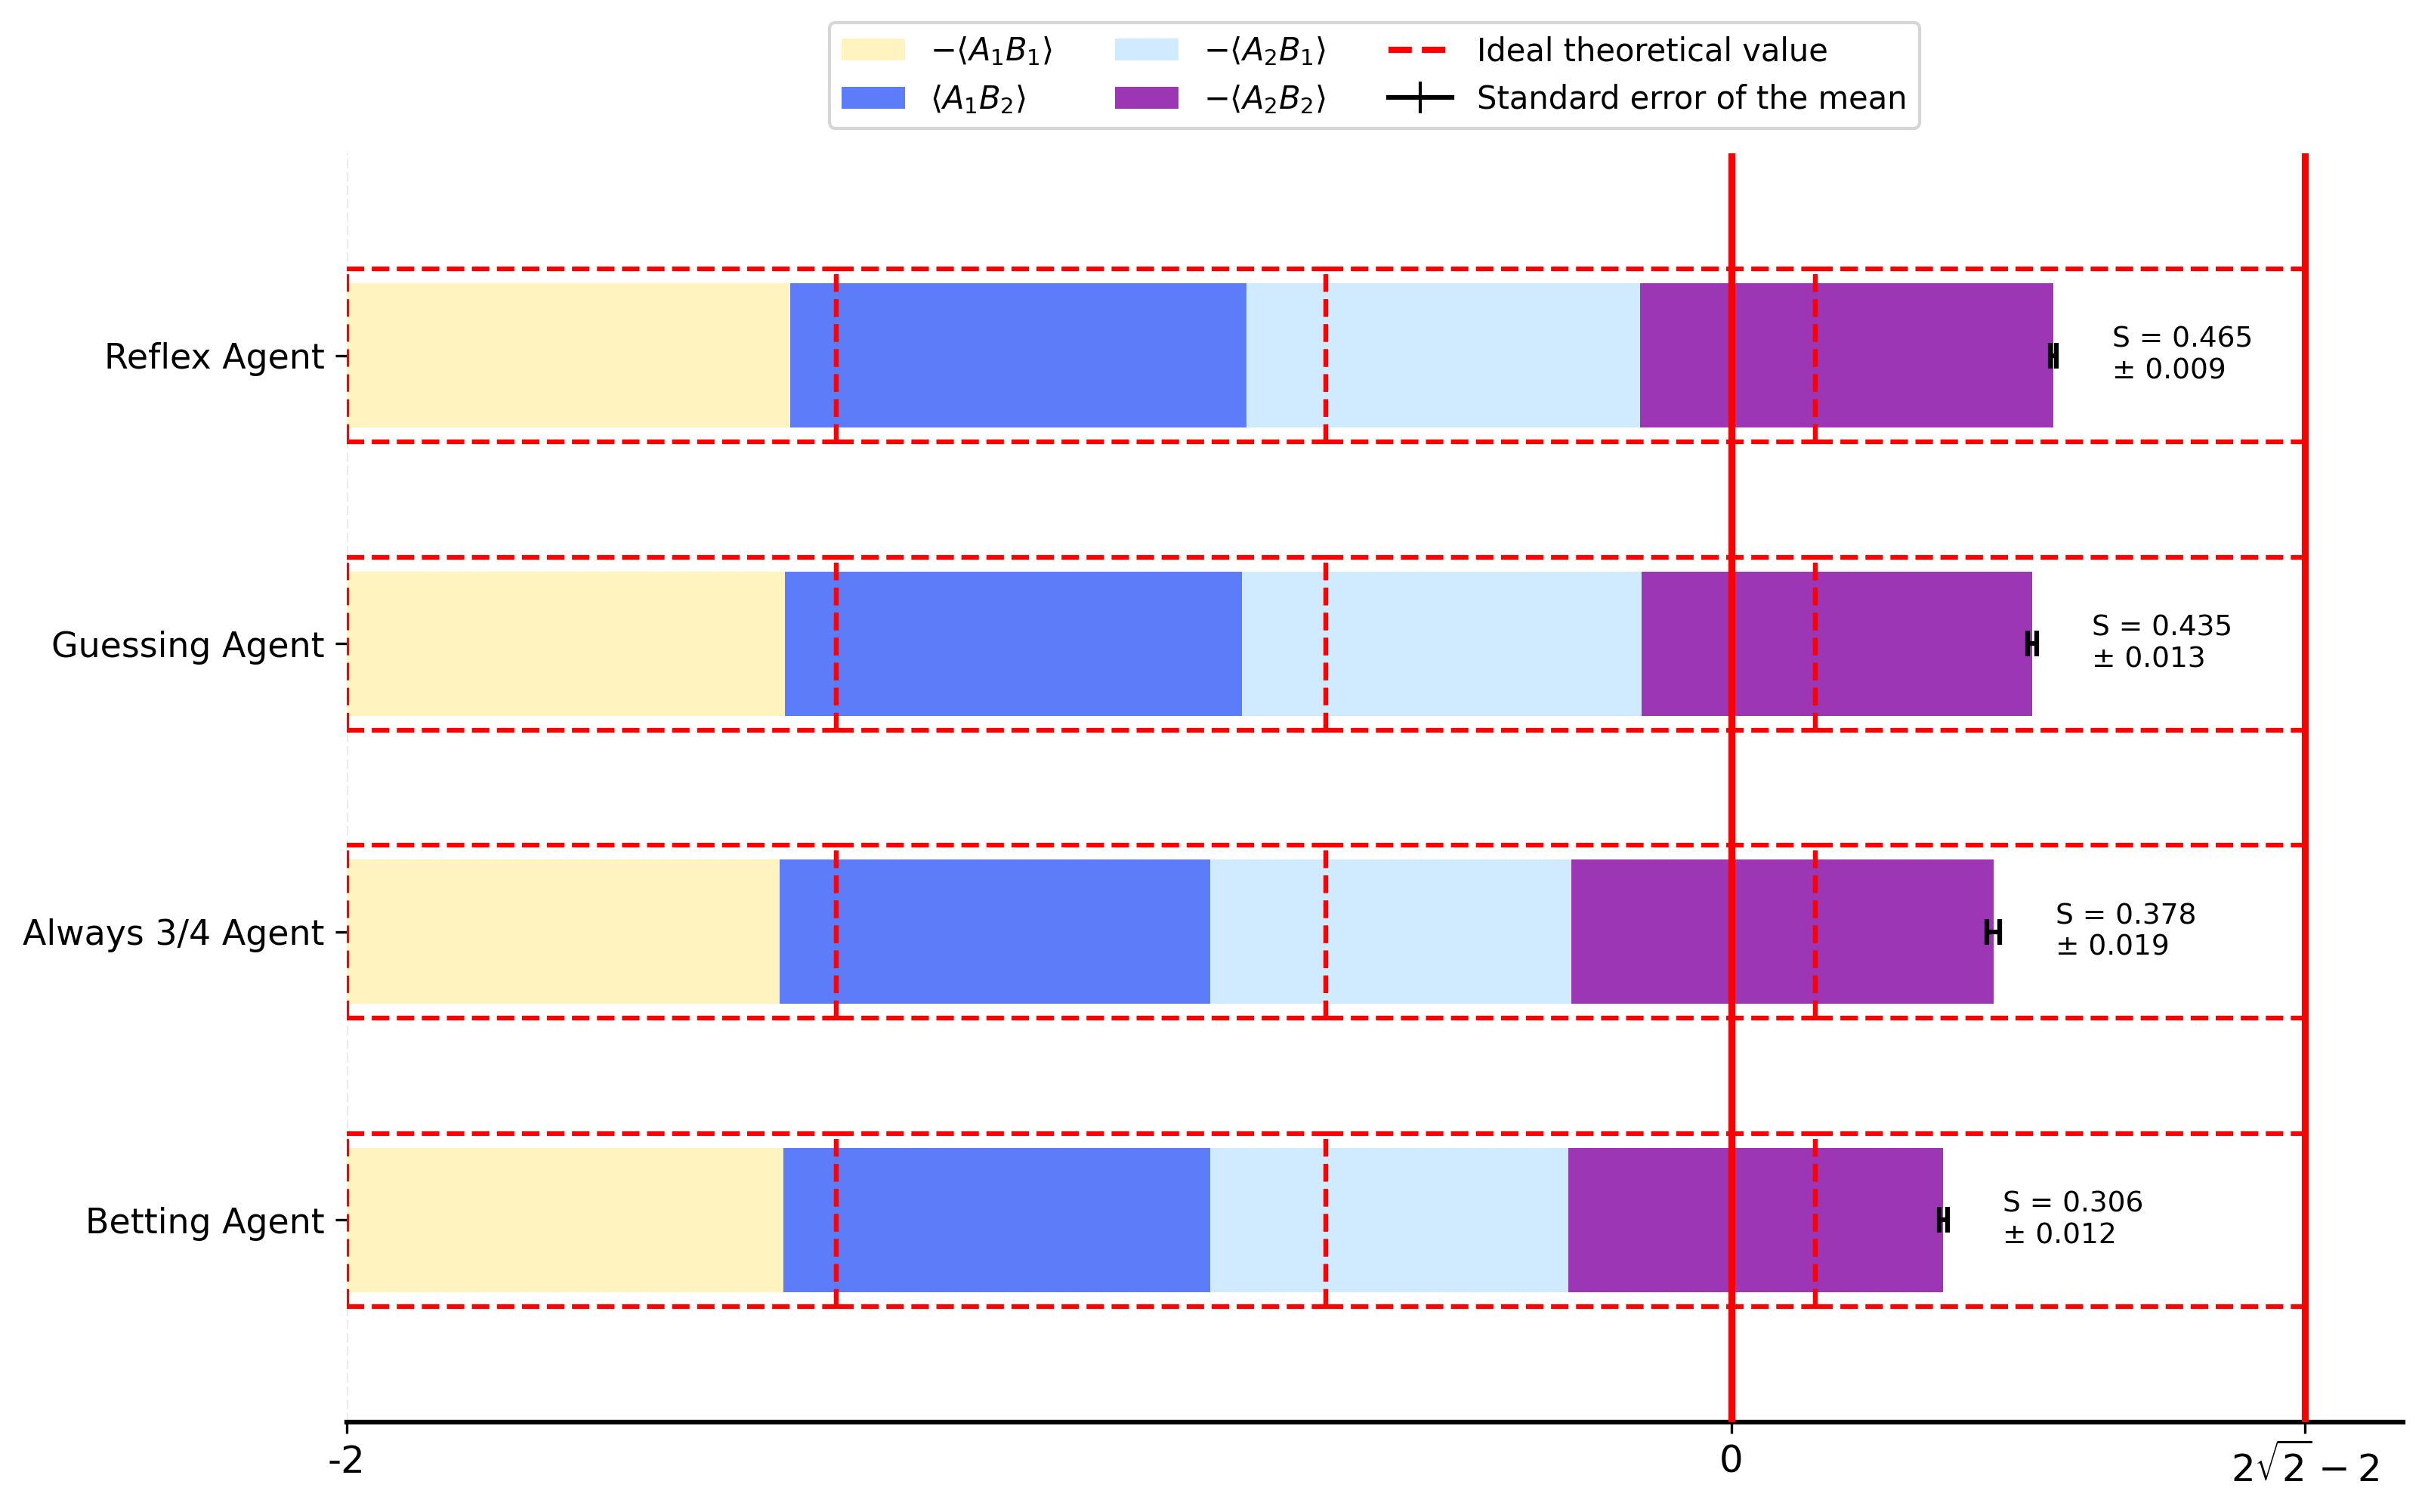

### Noiseless LF correlators: Reflex Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_reflex_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_reflex_agent_lf_correlator_comparison.pdf


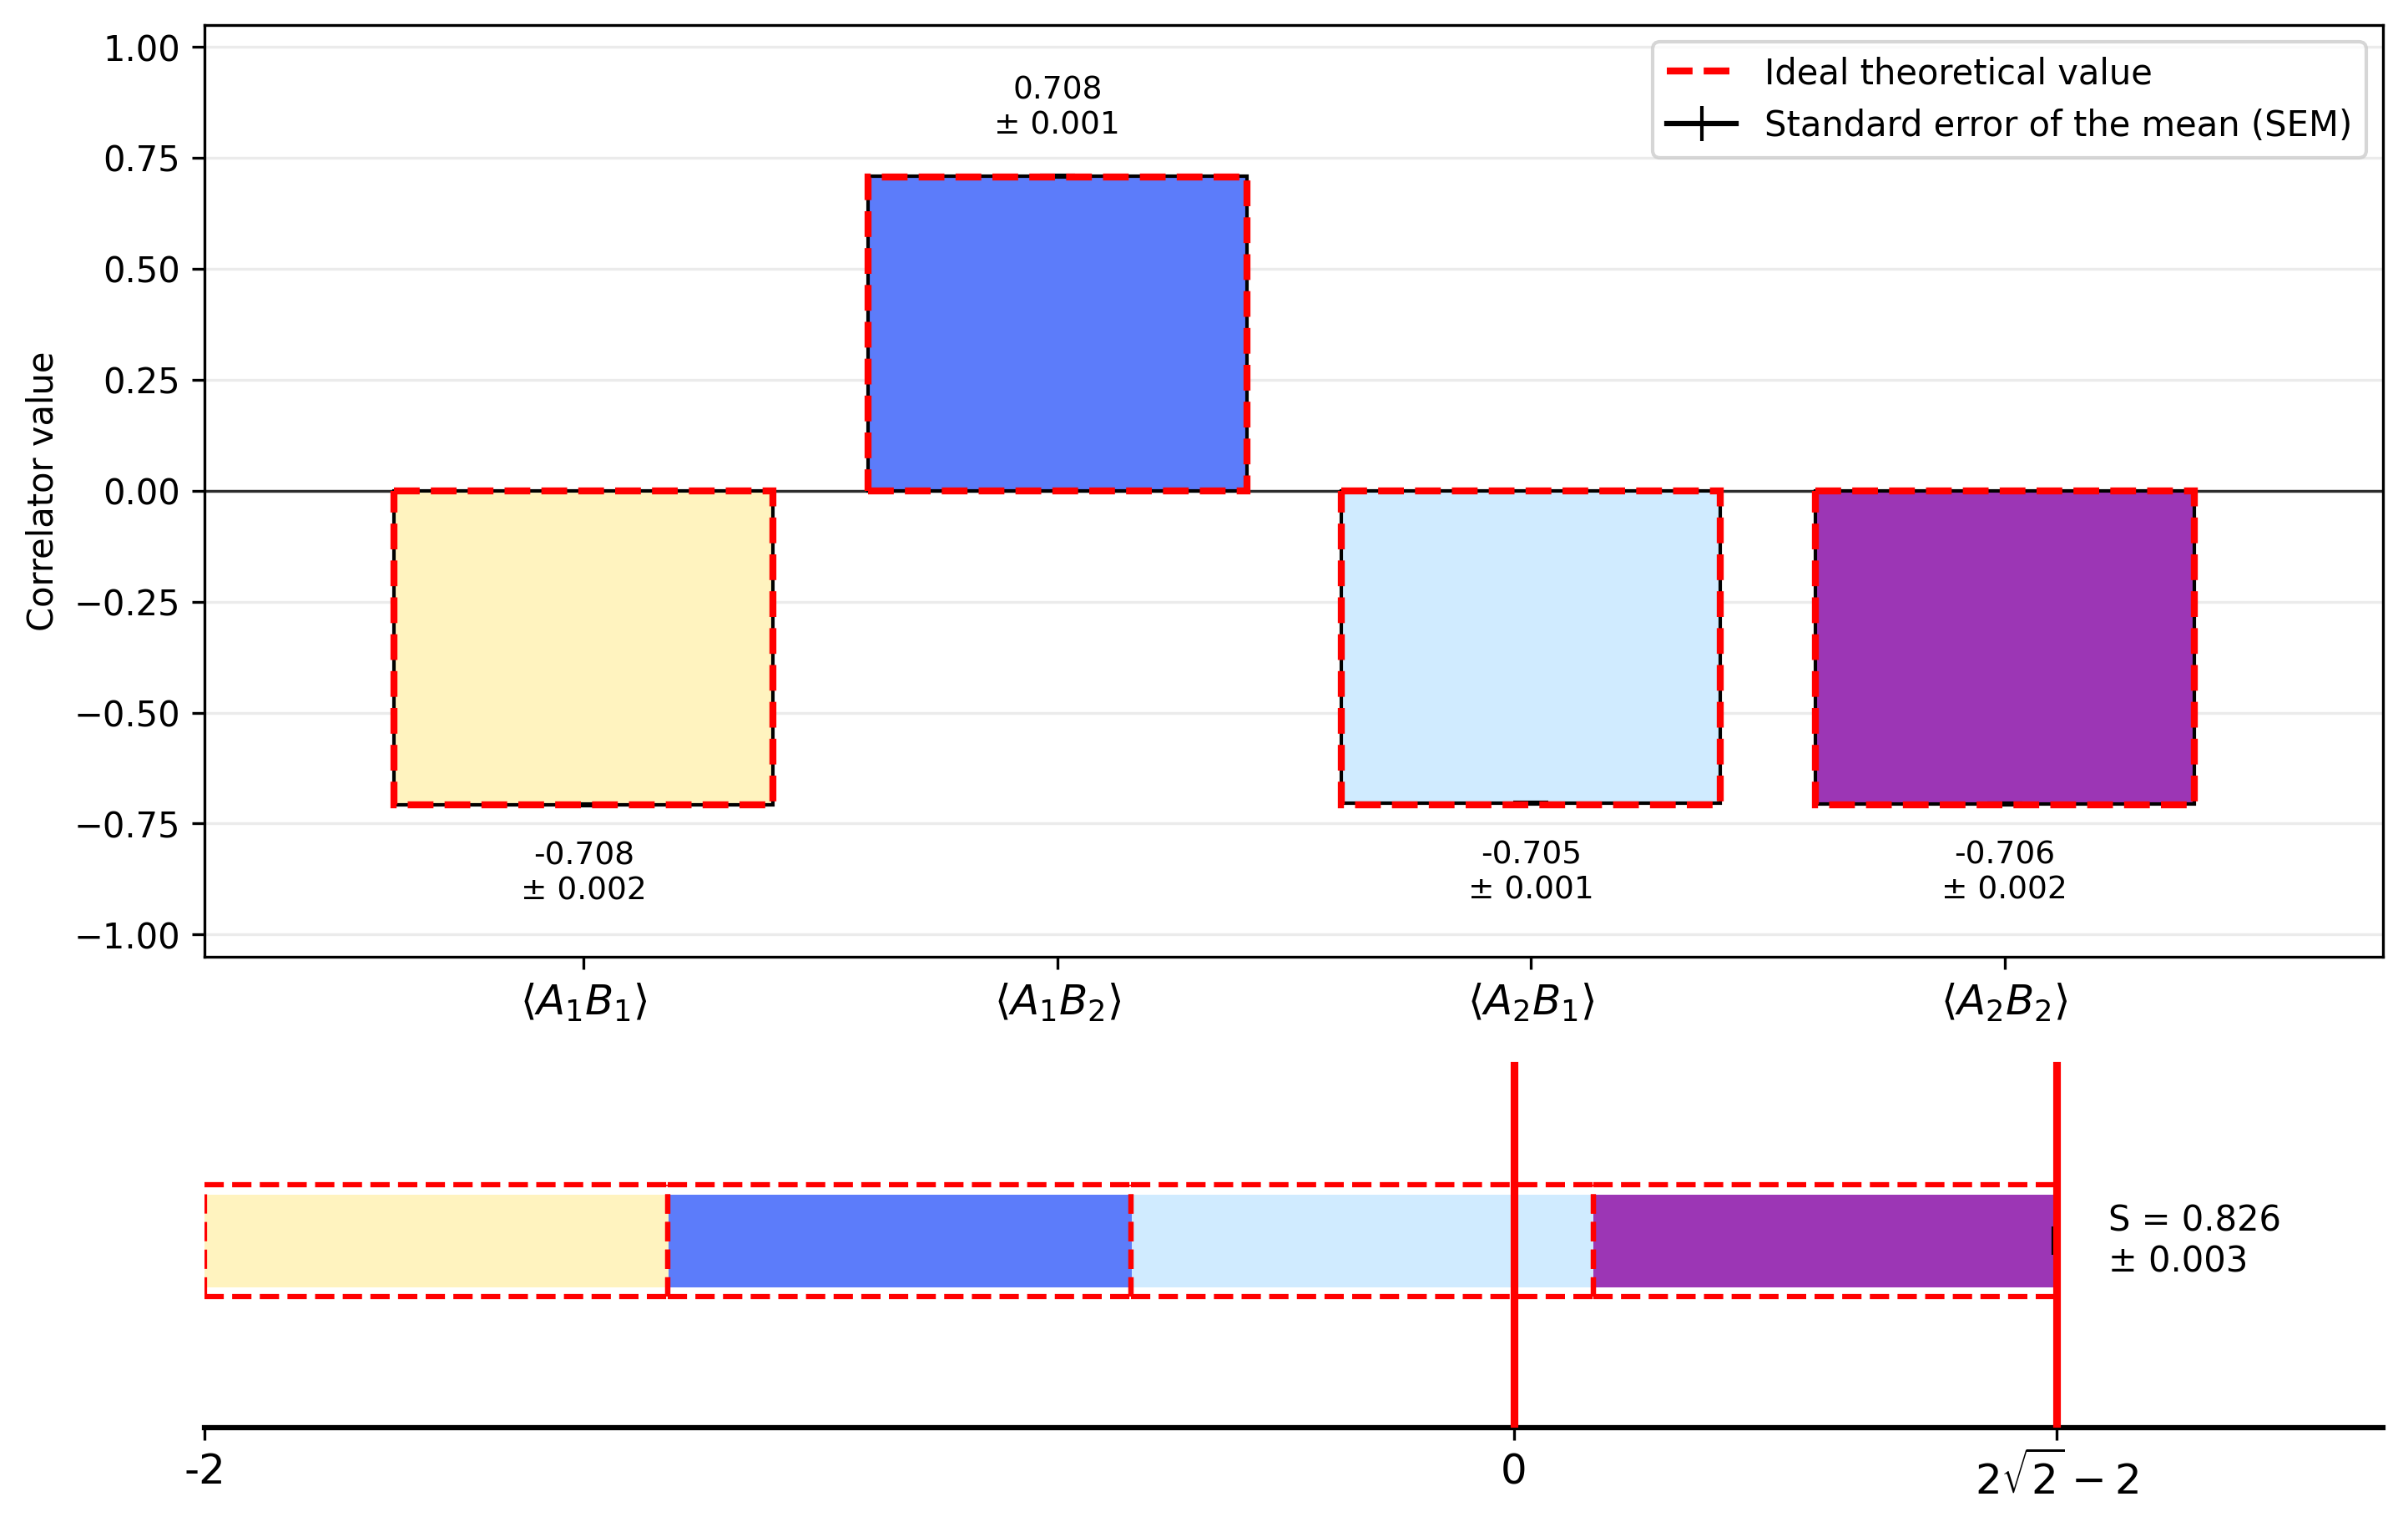

### Noise simulation and hardware LF correlators: Reflex Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_reflex_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_reflex_agent_lf_correlator_comparison.pdf


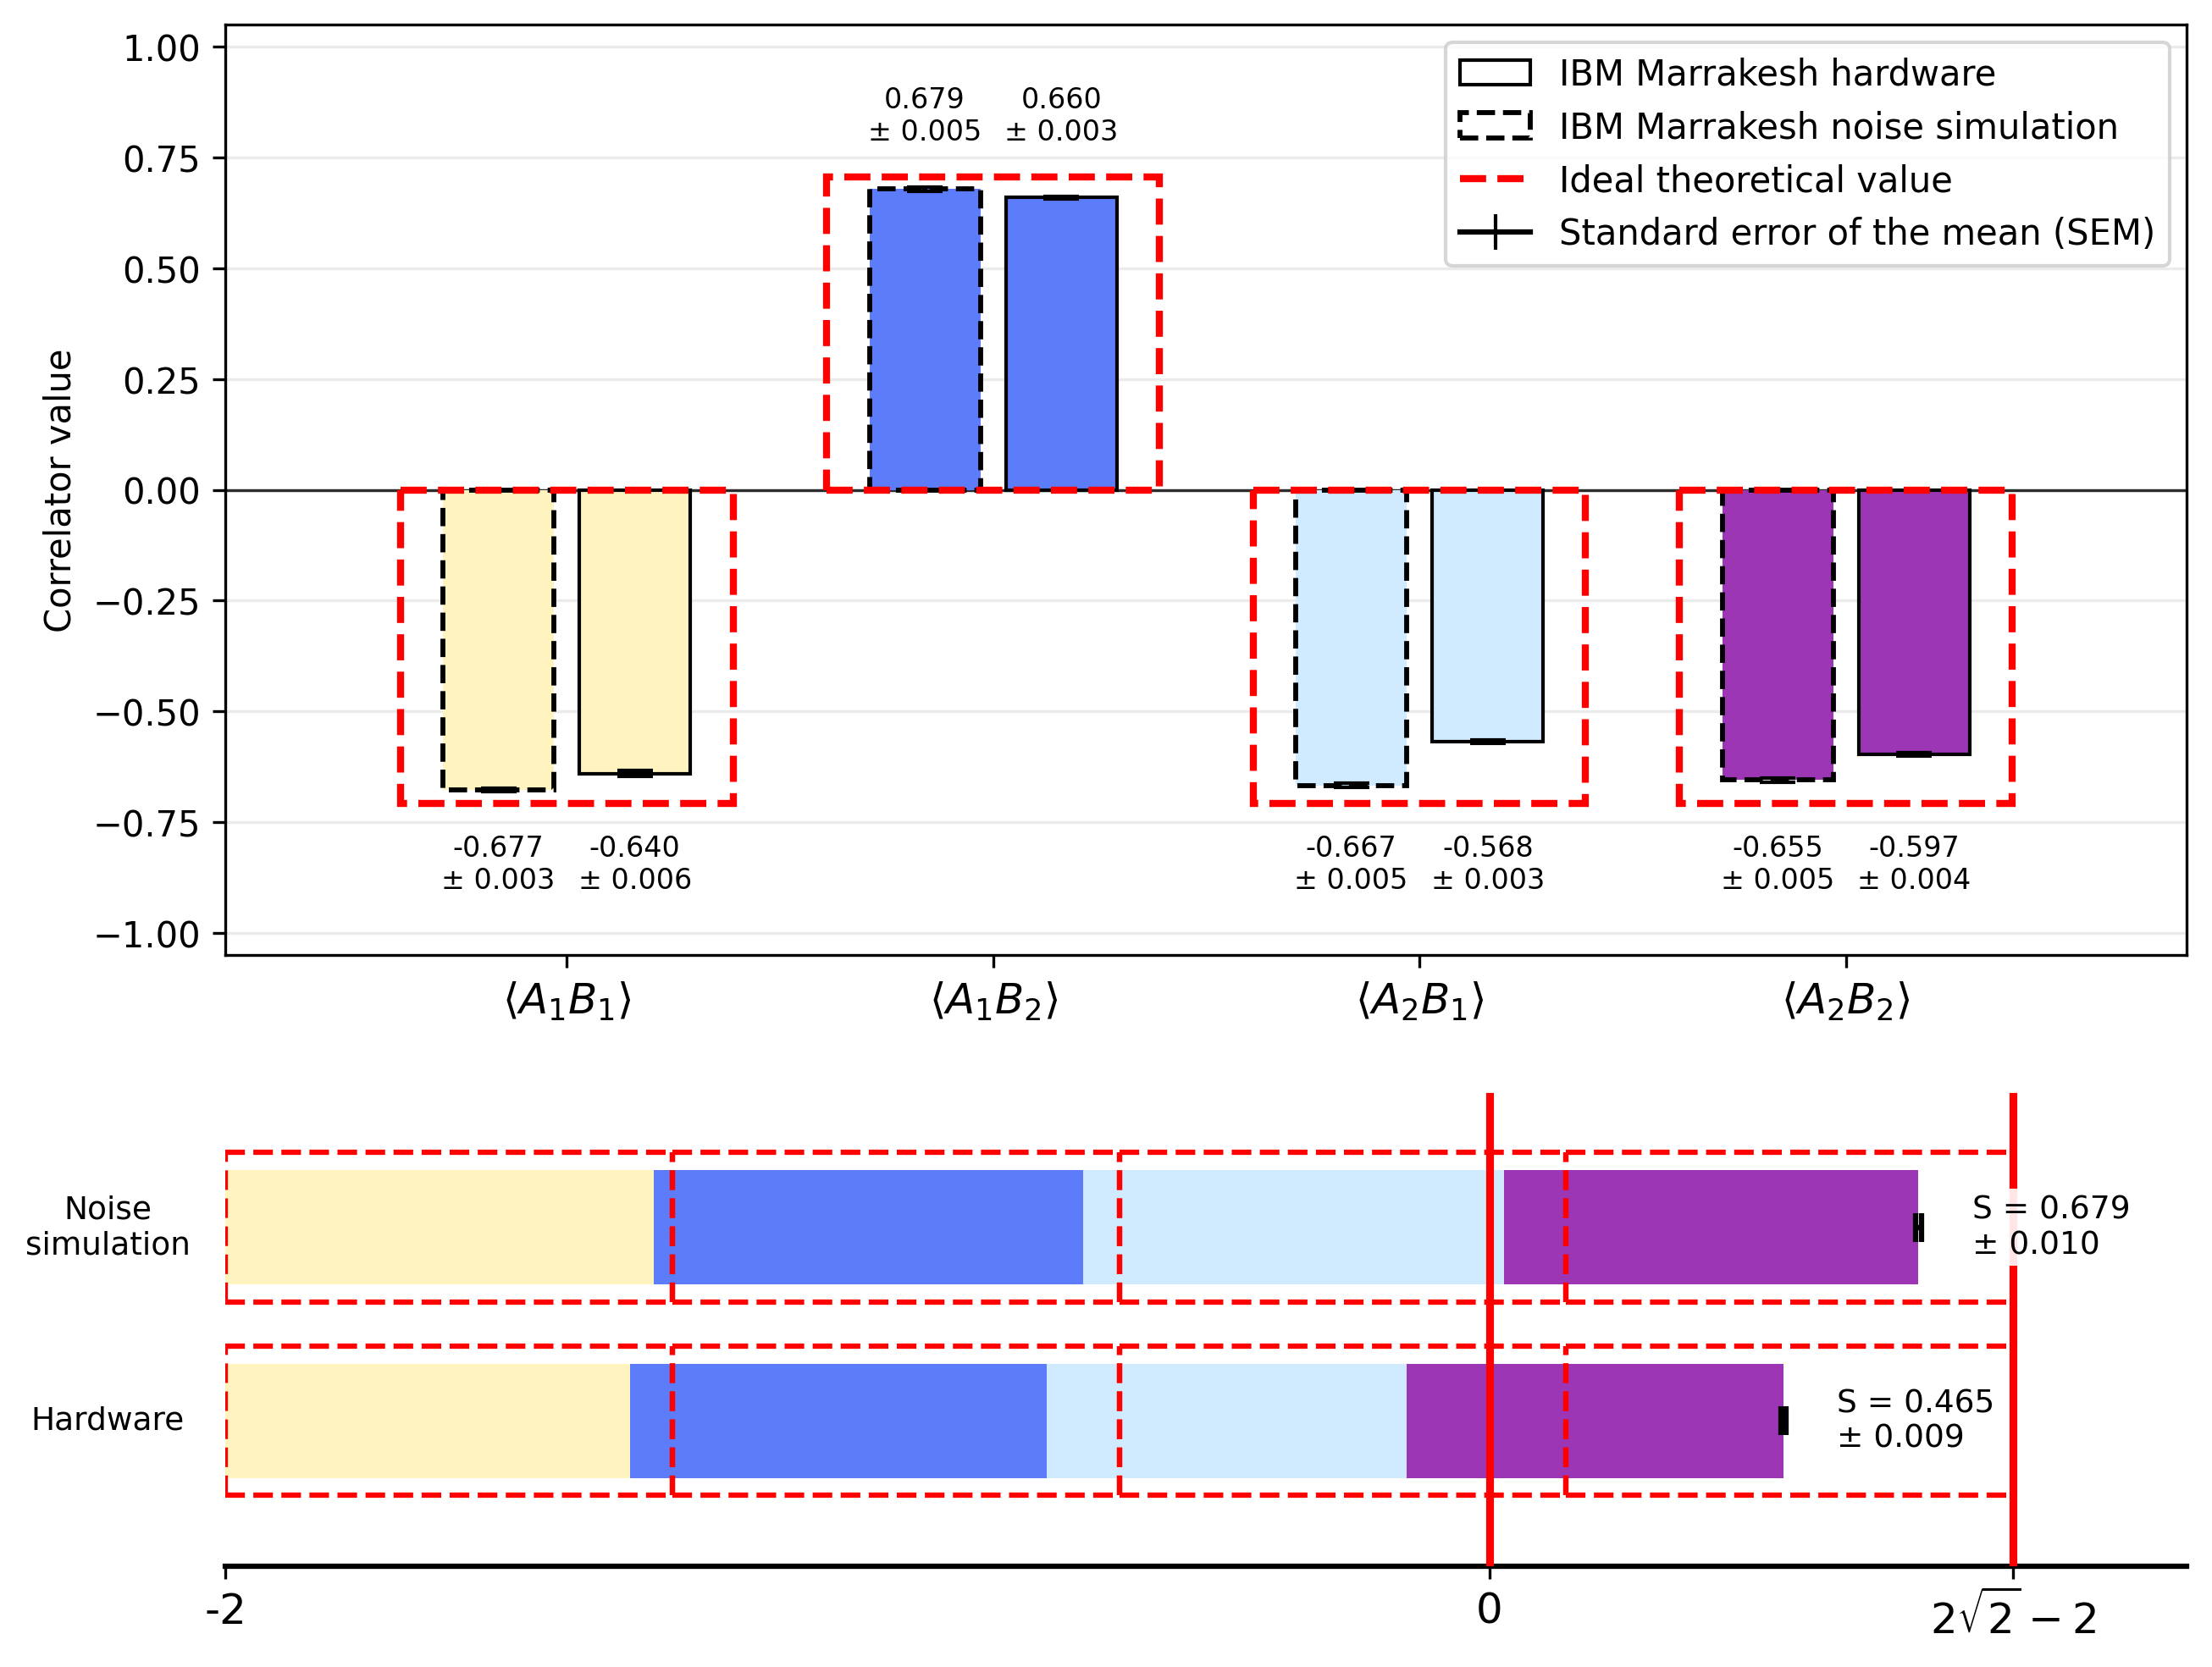

### Noiseless LF correlators: Guessing Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_guessing_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_guessing_agent_lf_correlator_comparison.pdf


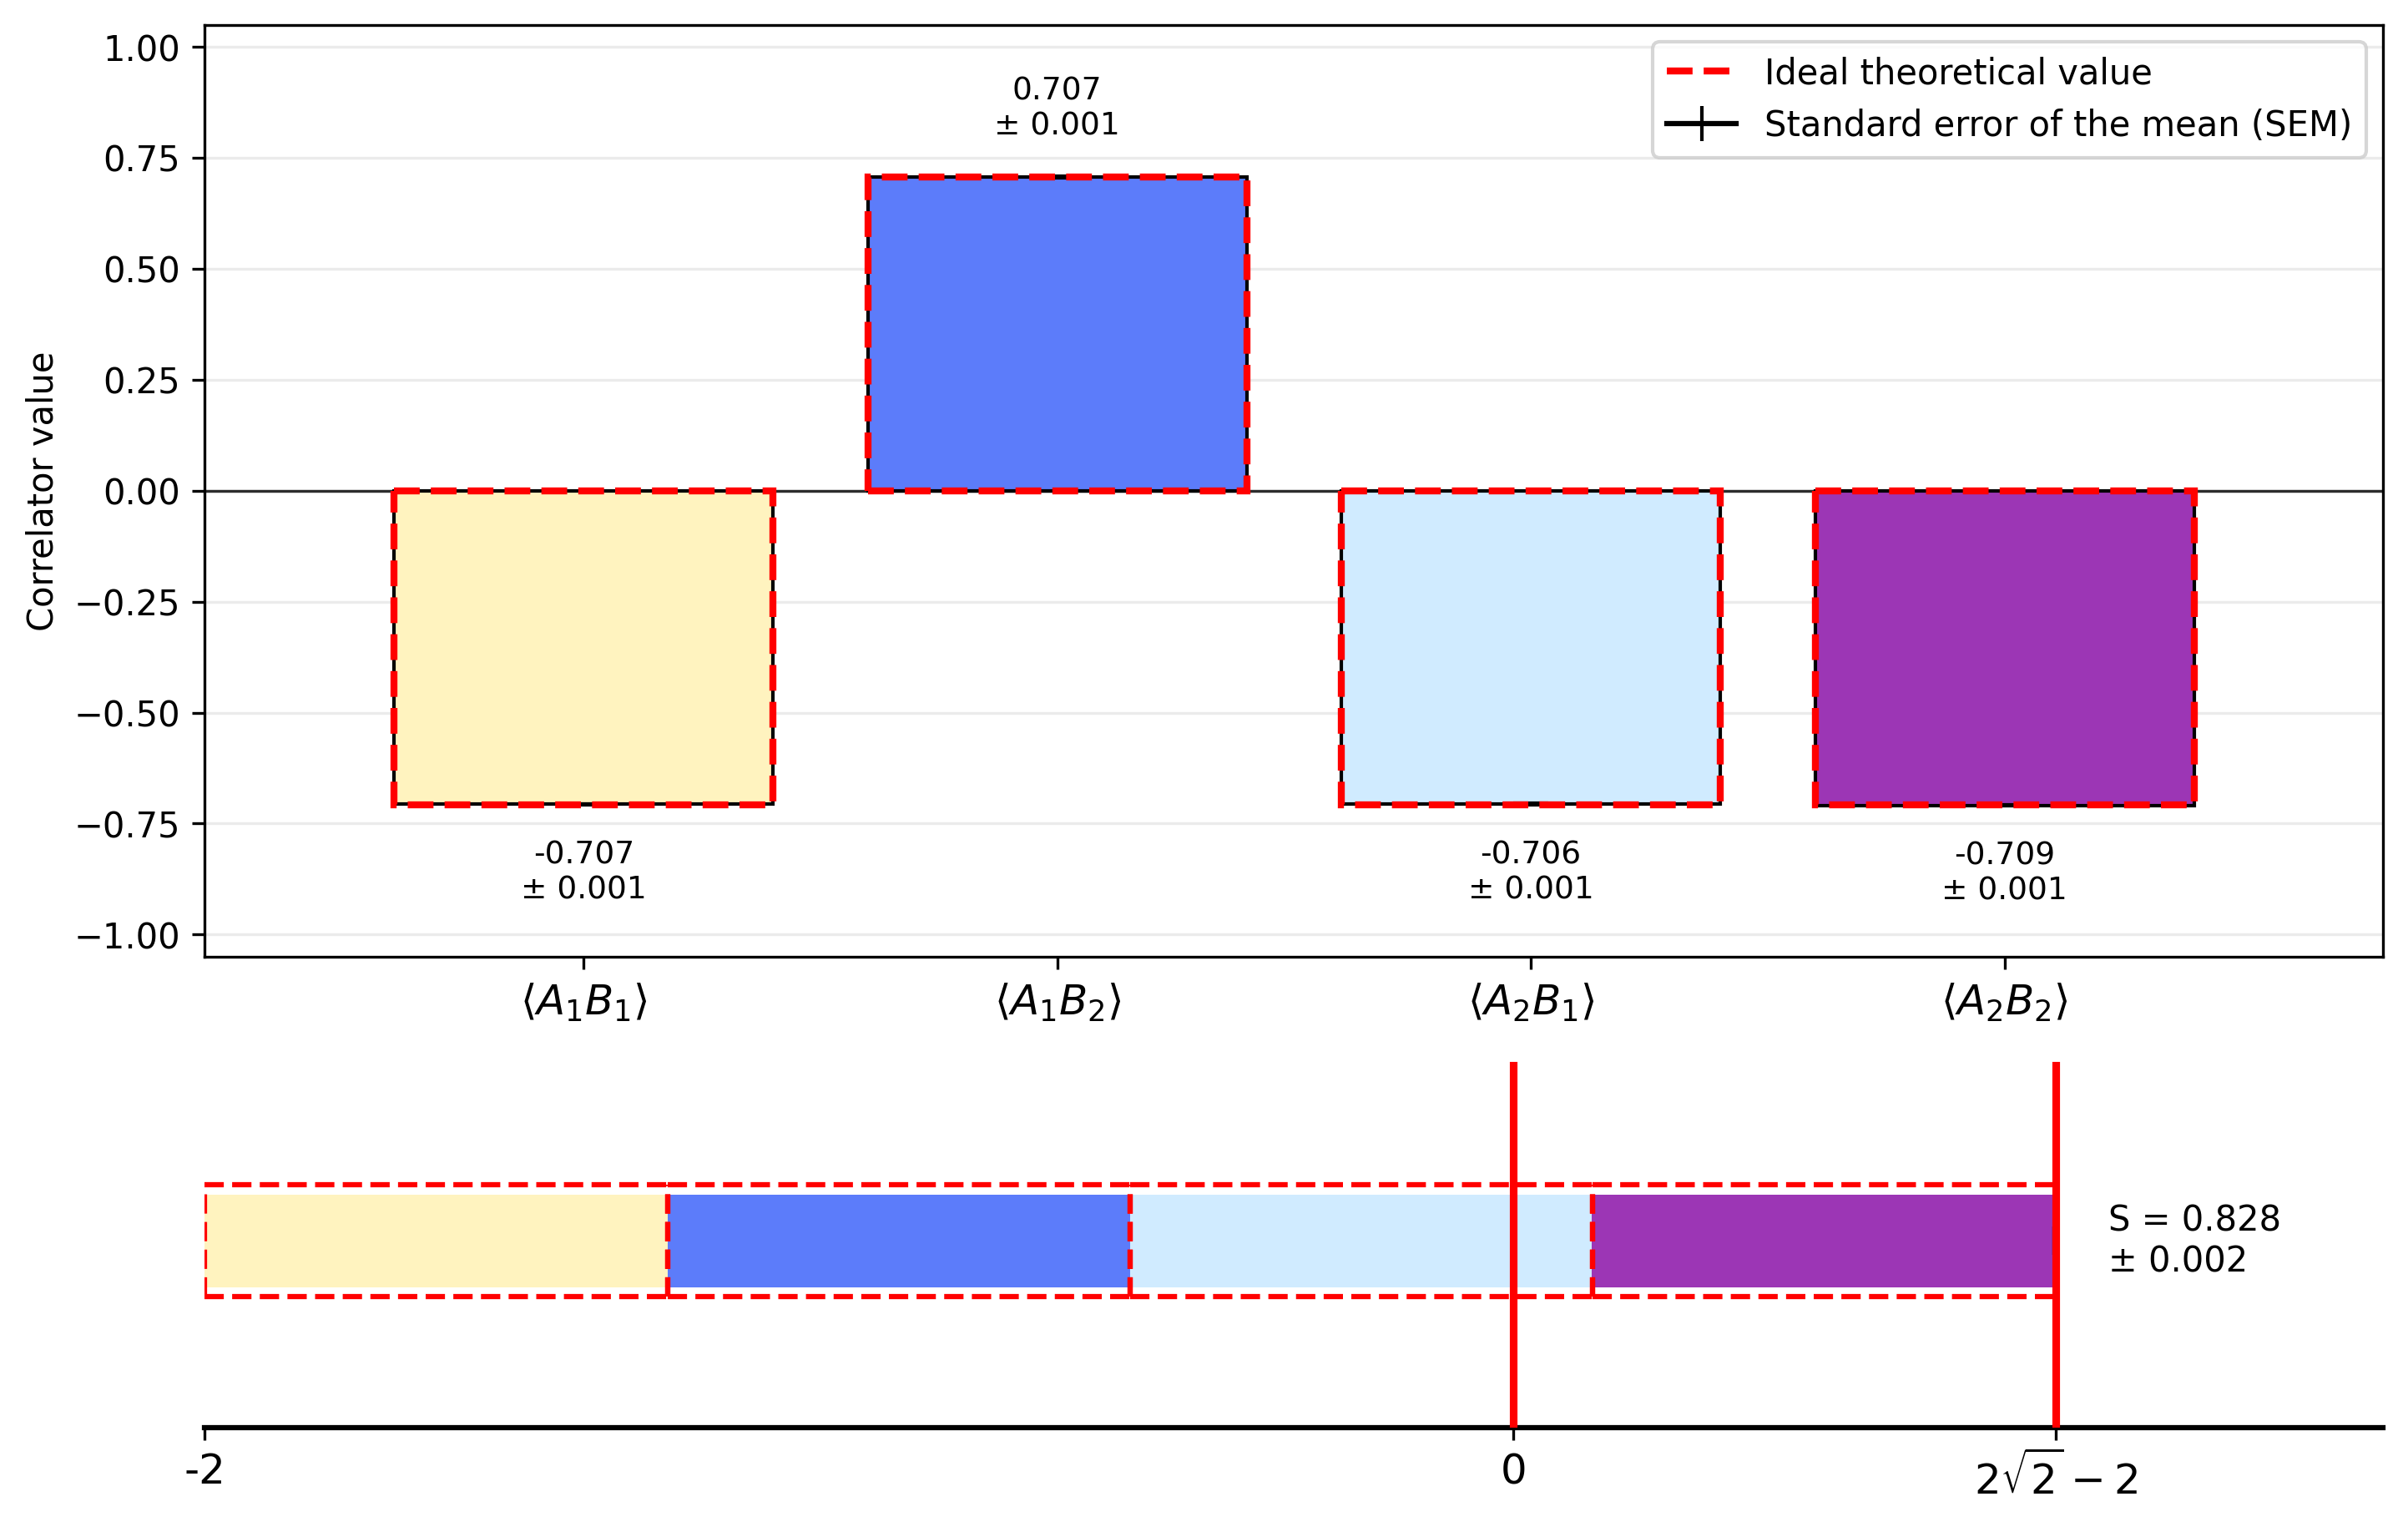

### Noise simulation and hardware LF correlators: Guessing Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_guessing_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_guessing_agent_lf_correlator_comparison.pdf


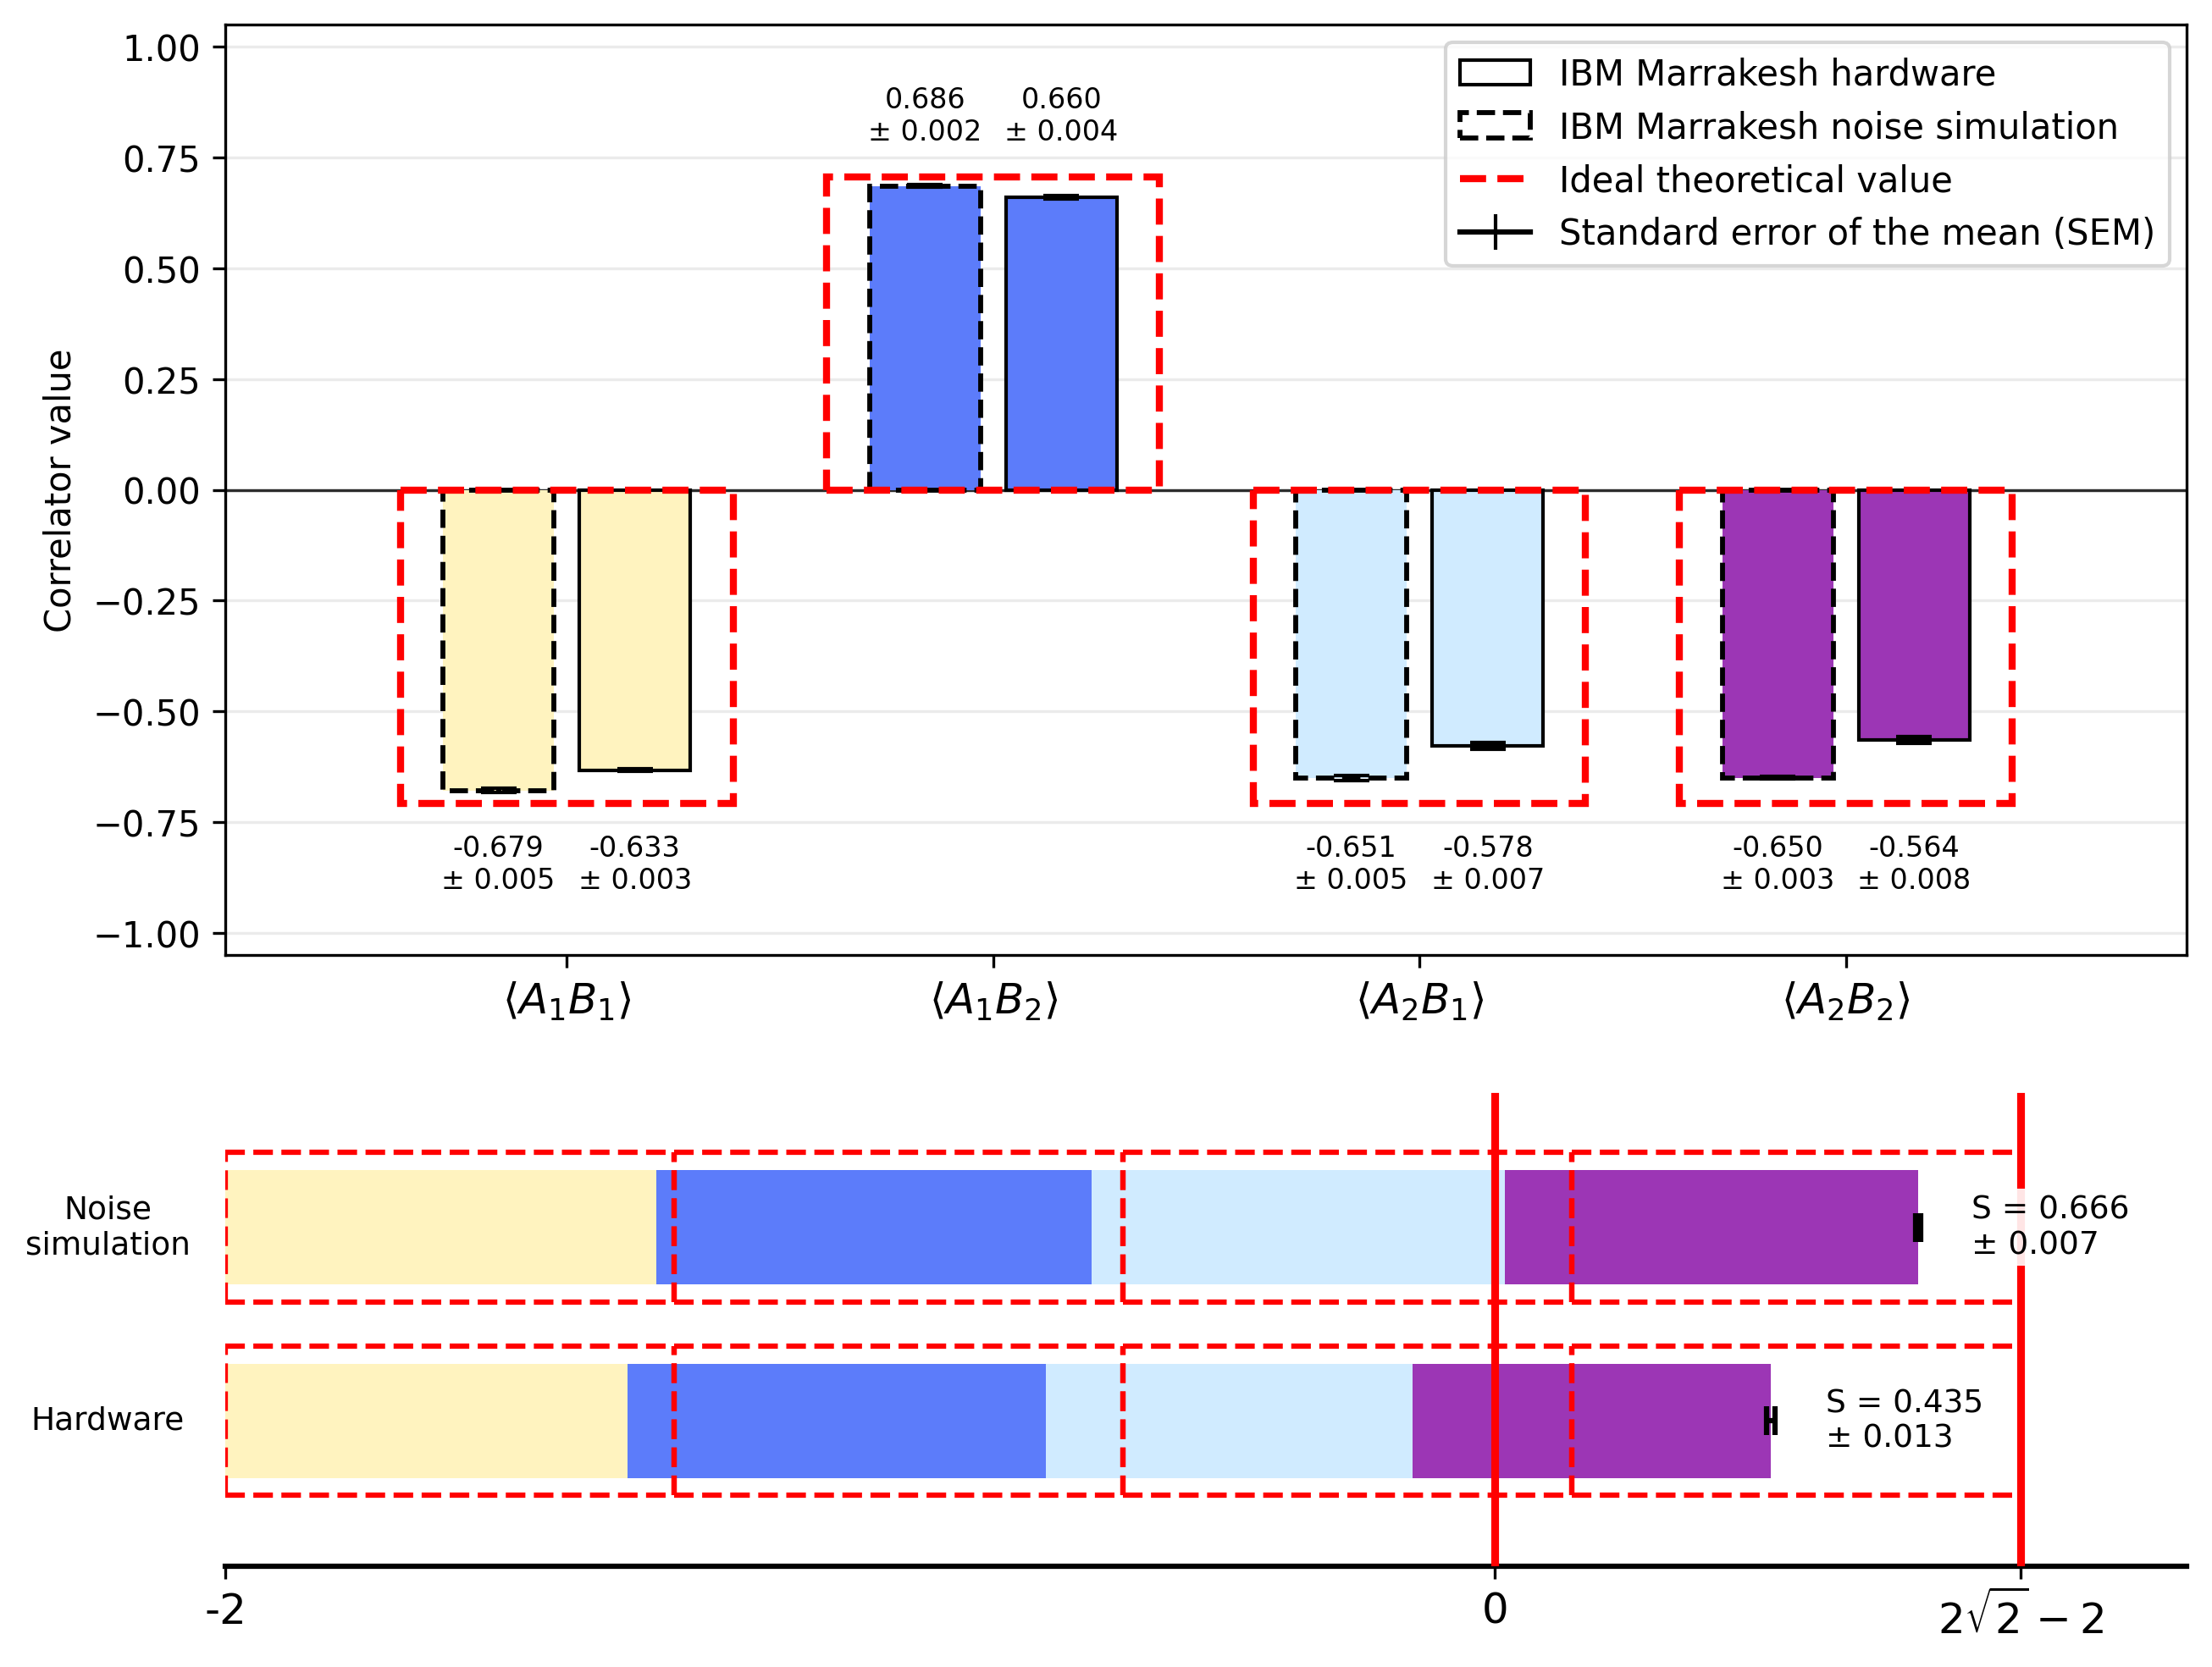

### Noiseless LF correlators: Always 3/4 Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_always_3_4_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_always_3_4_agent_lf_correlator_comparison.pdf


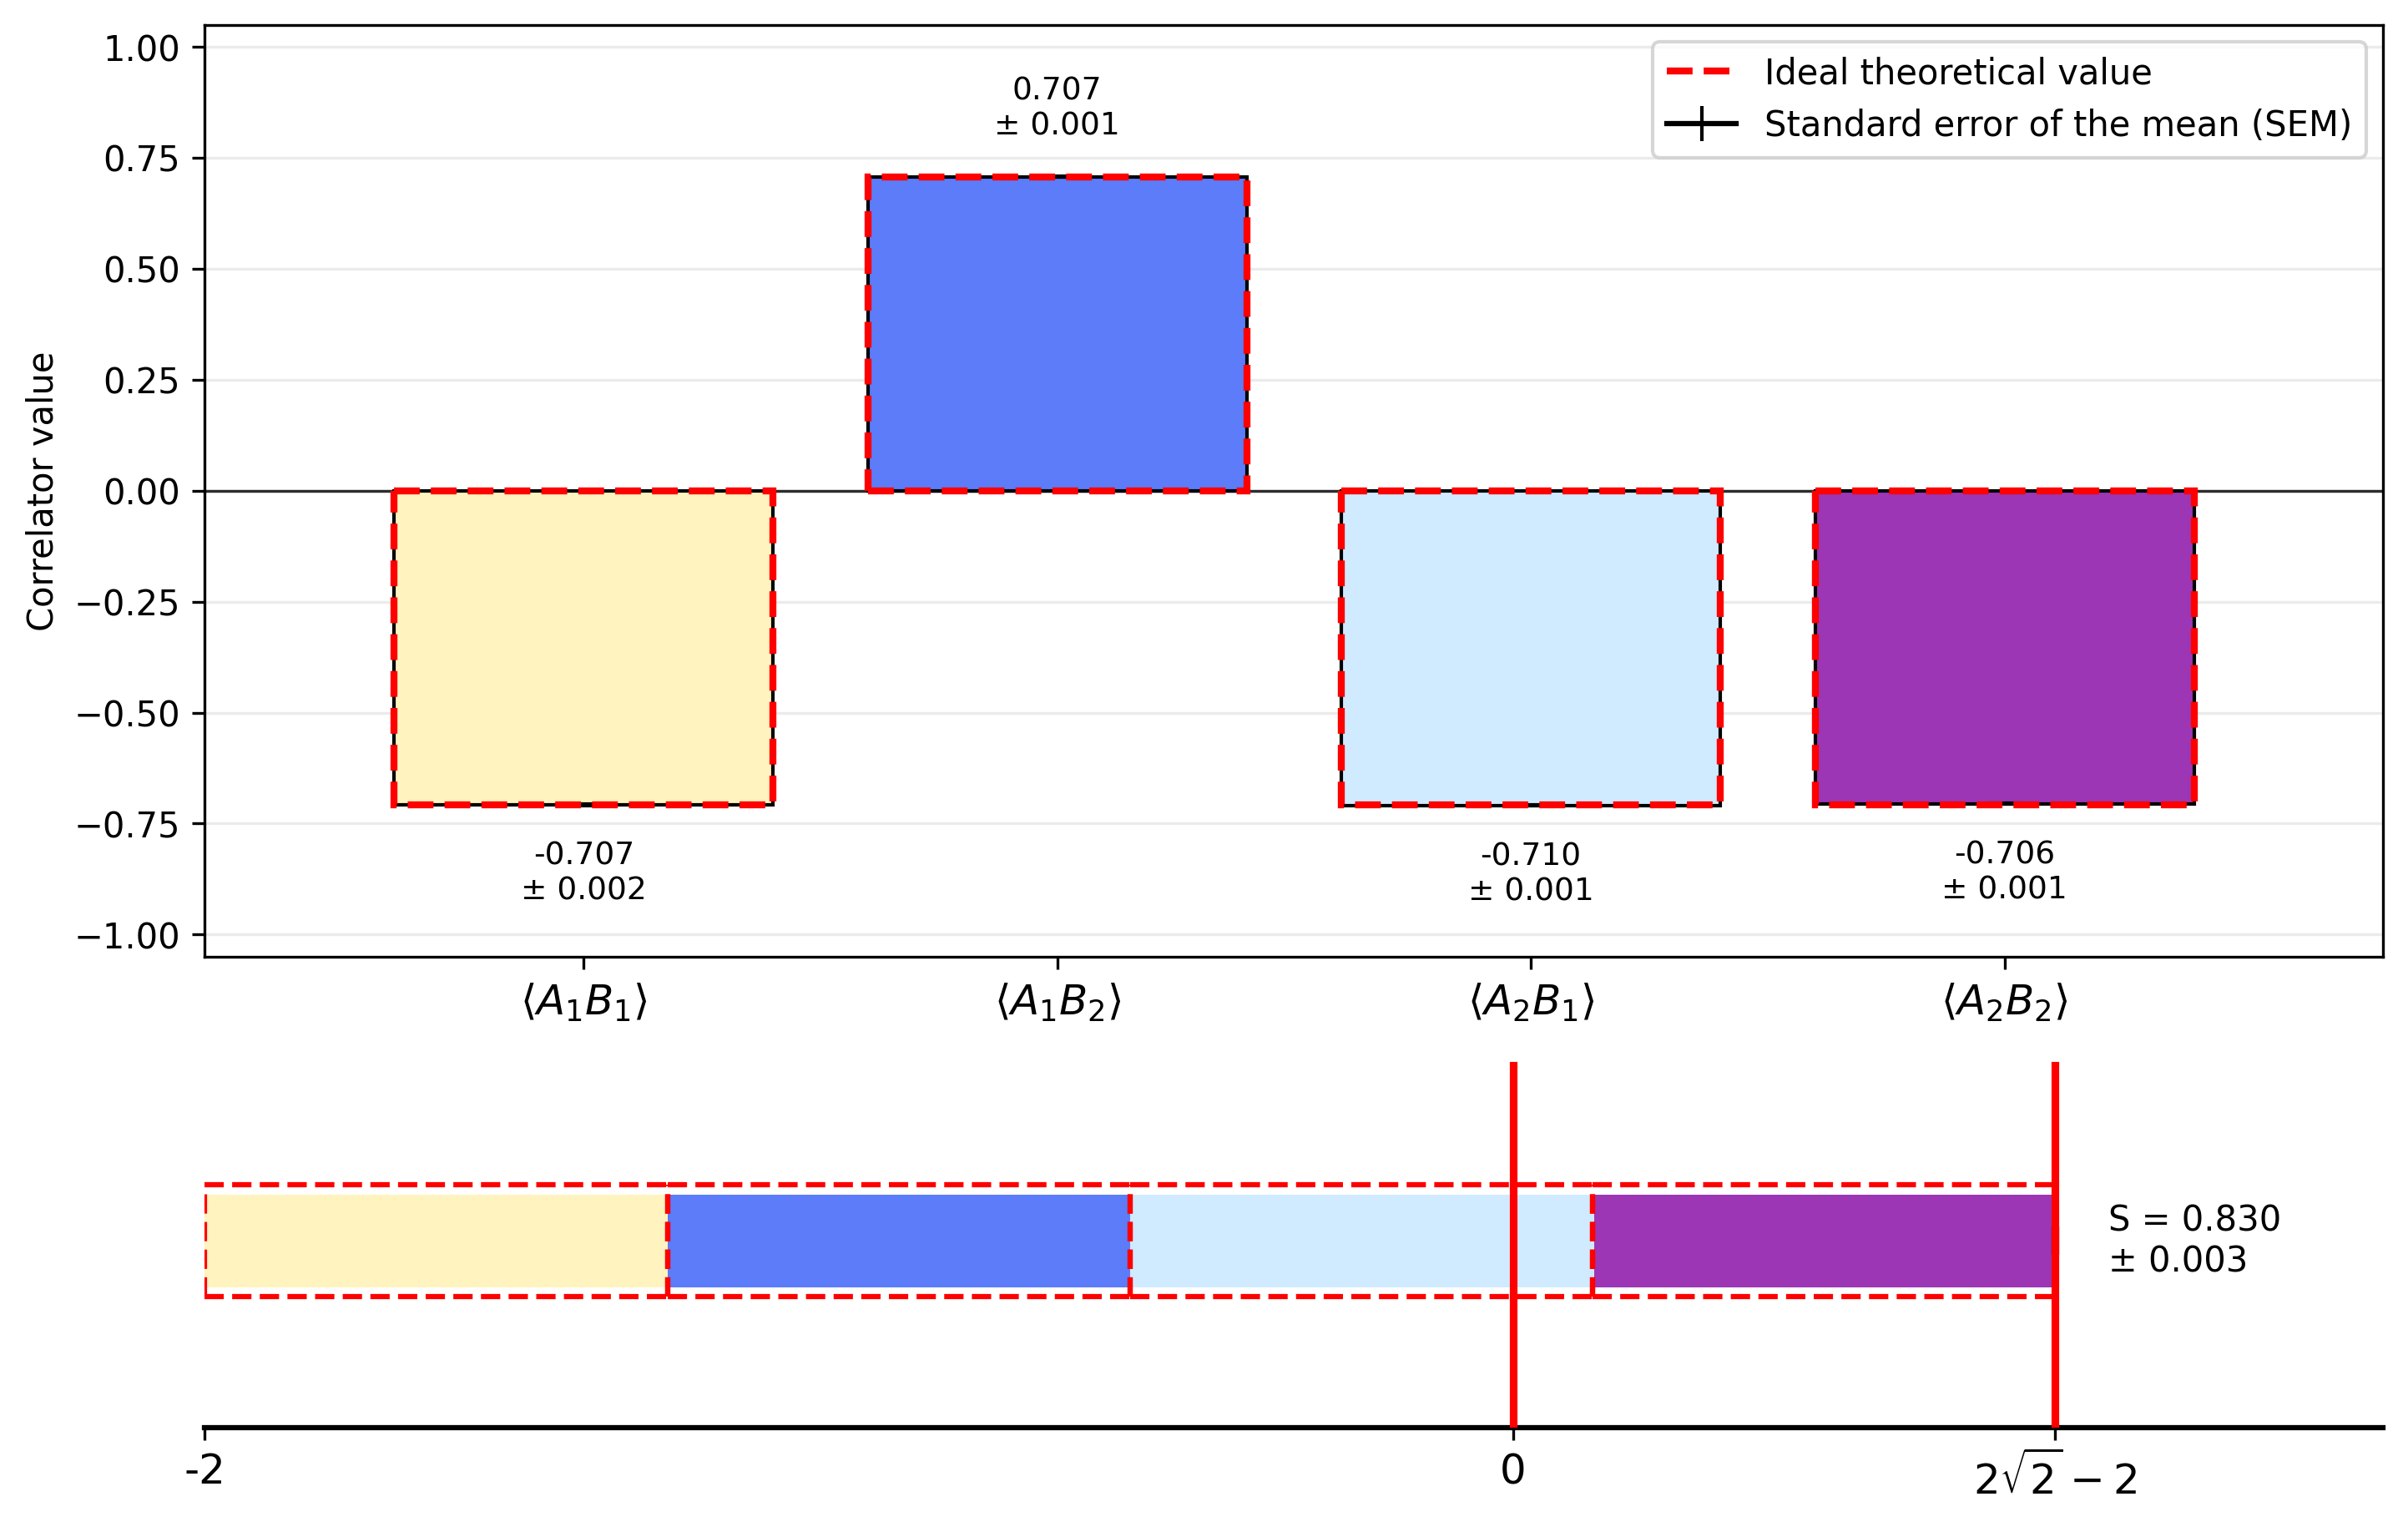

### Noise simulation and hardware LF correlators: Always 3/4 Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_always_3_4_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_always_3_4_agent_lf_correlator_comparison.pdf


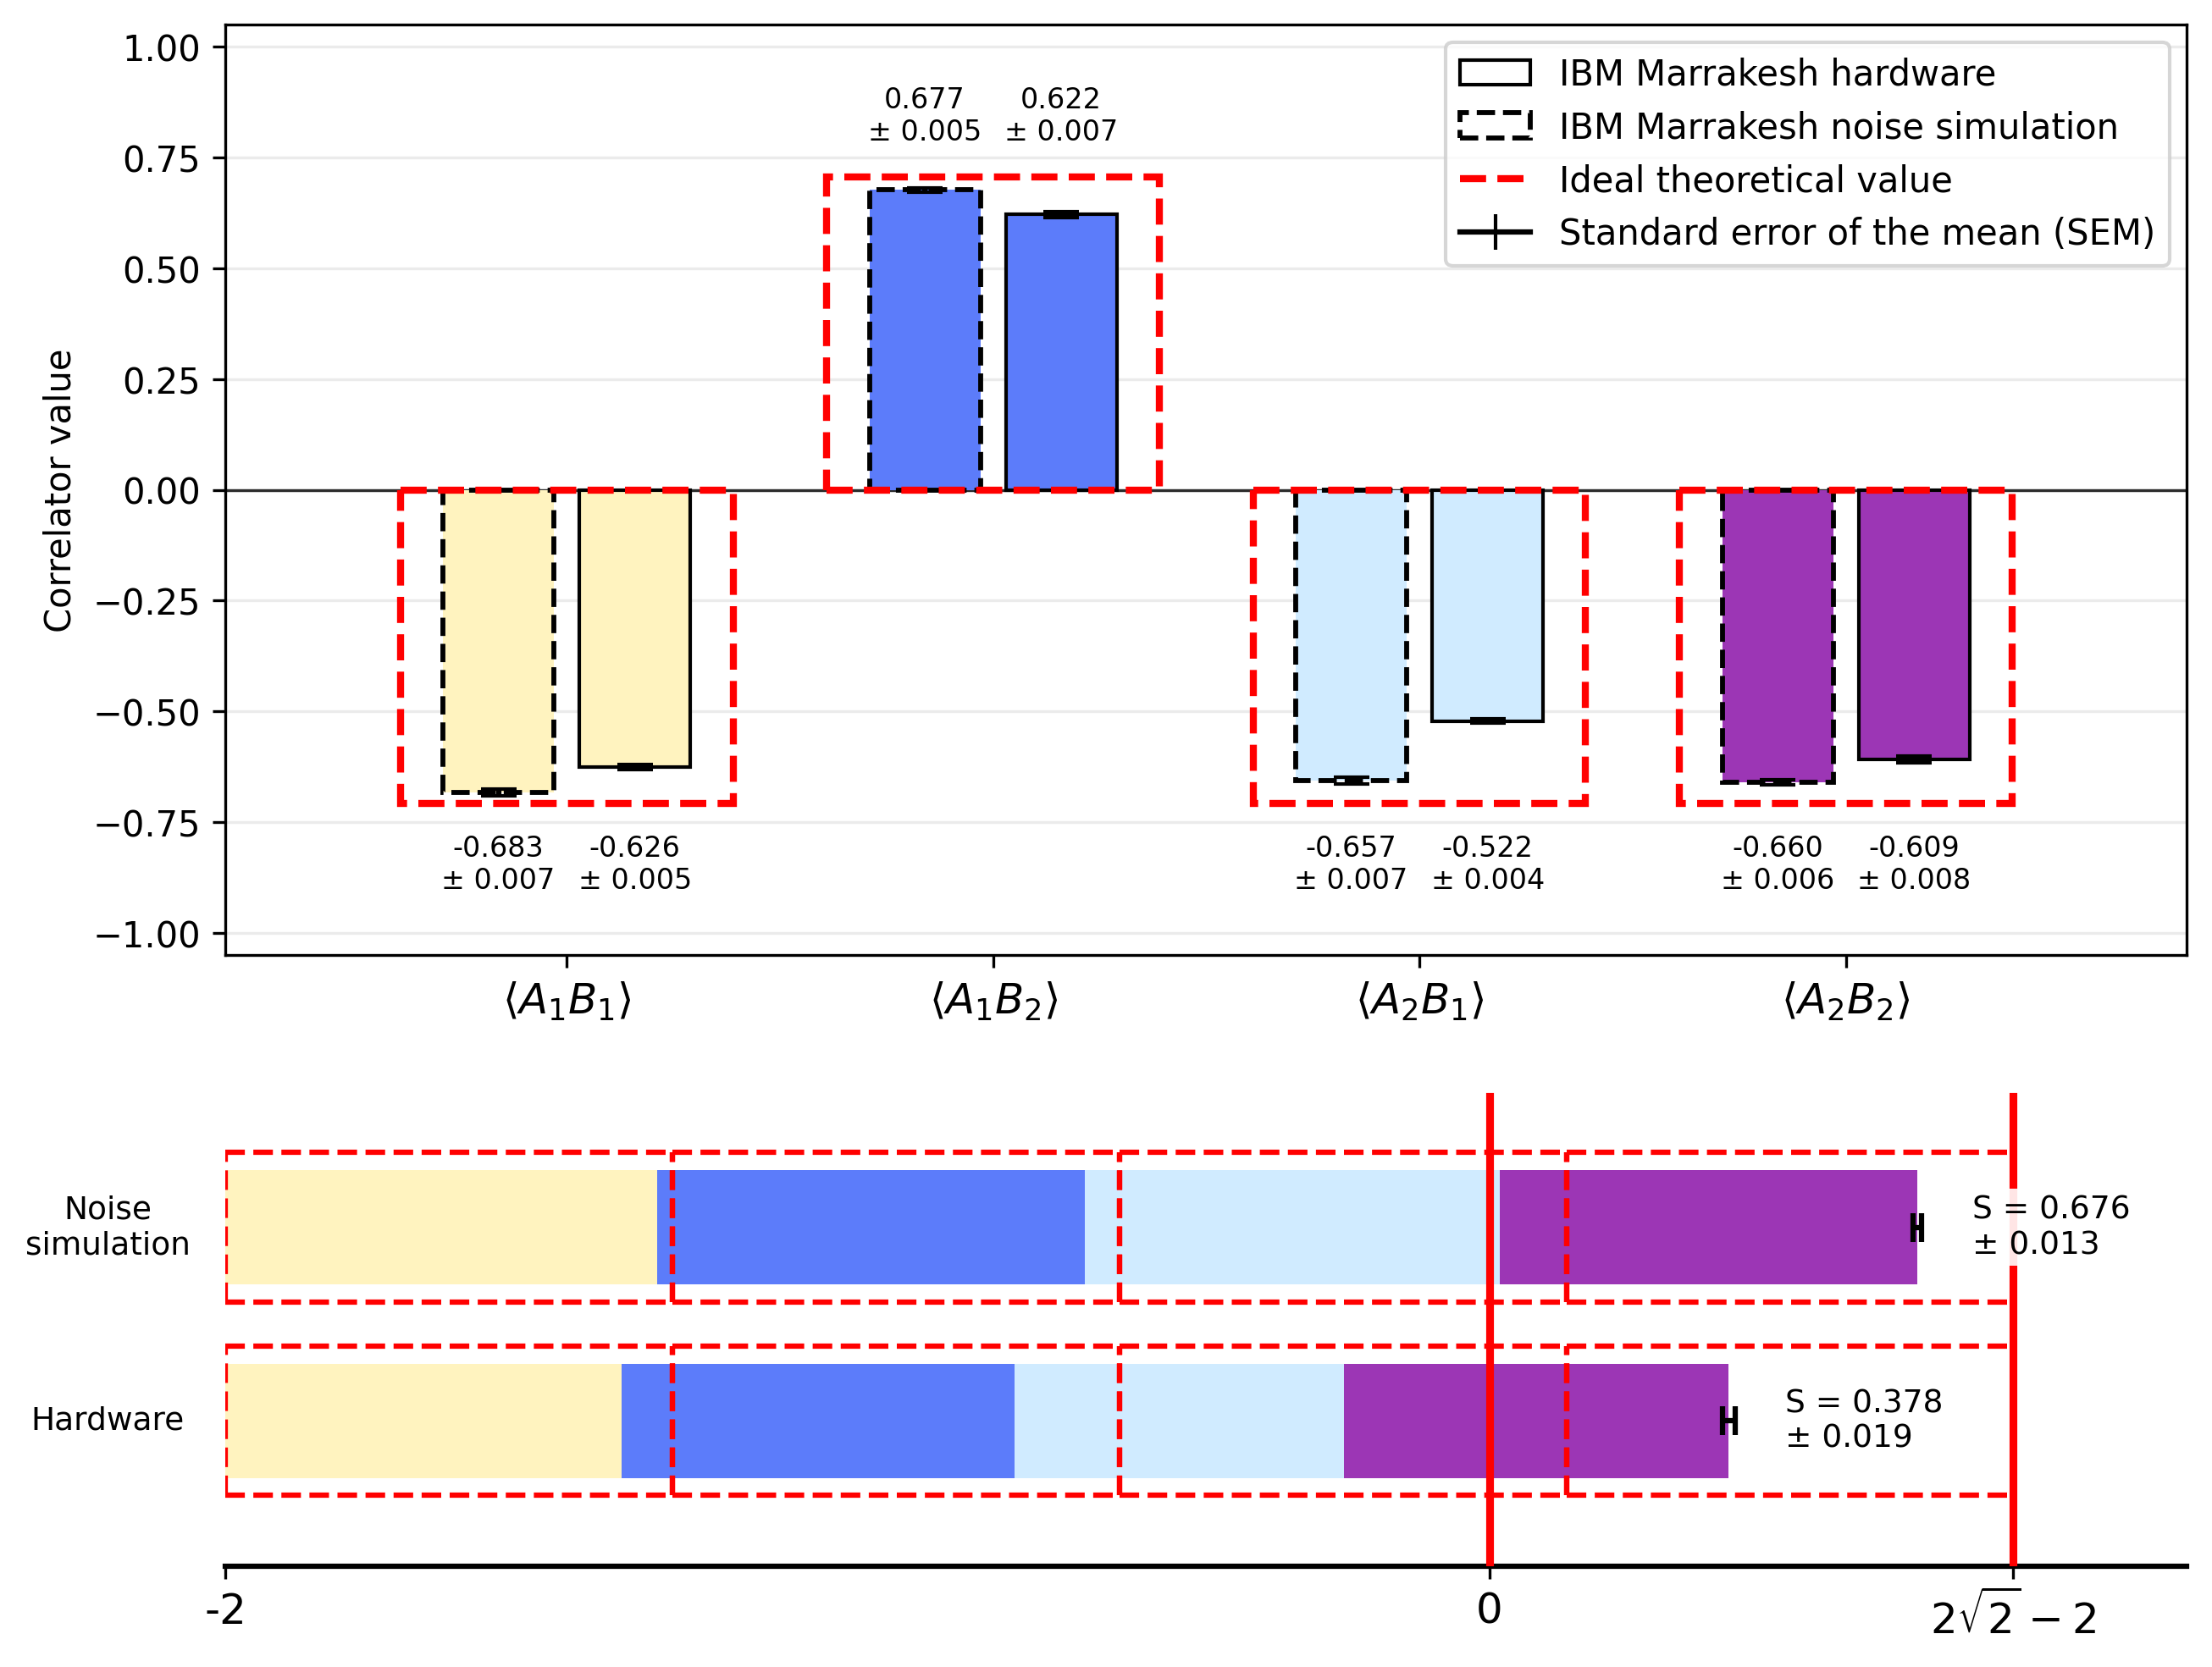

### Noiseless LF correlators: Betting Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_betting_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/agents/noiseless_betting_agent_lf_correlator_comparison.pdf


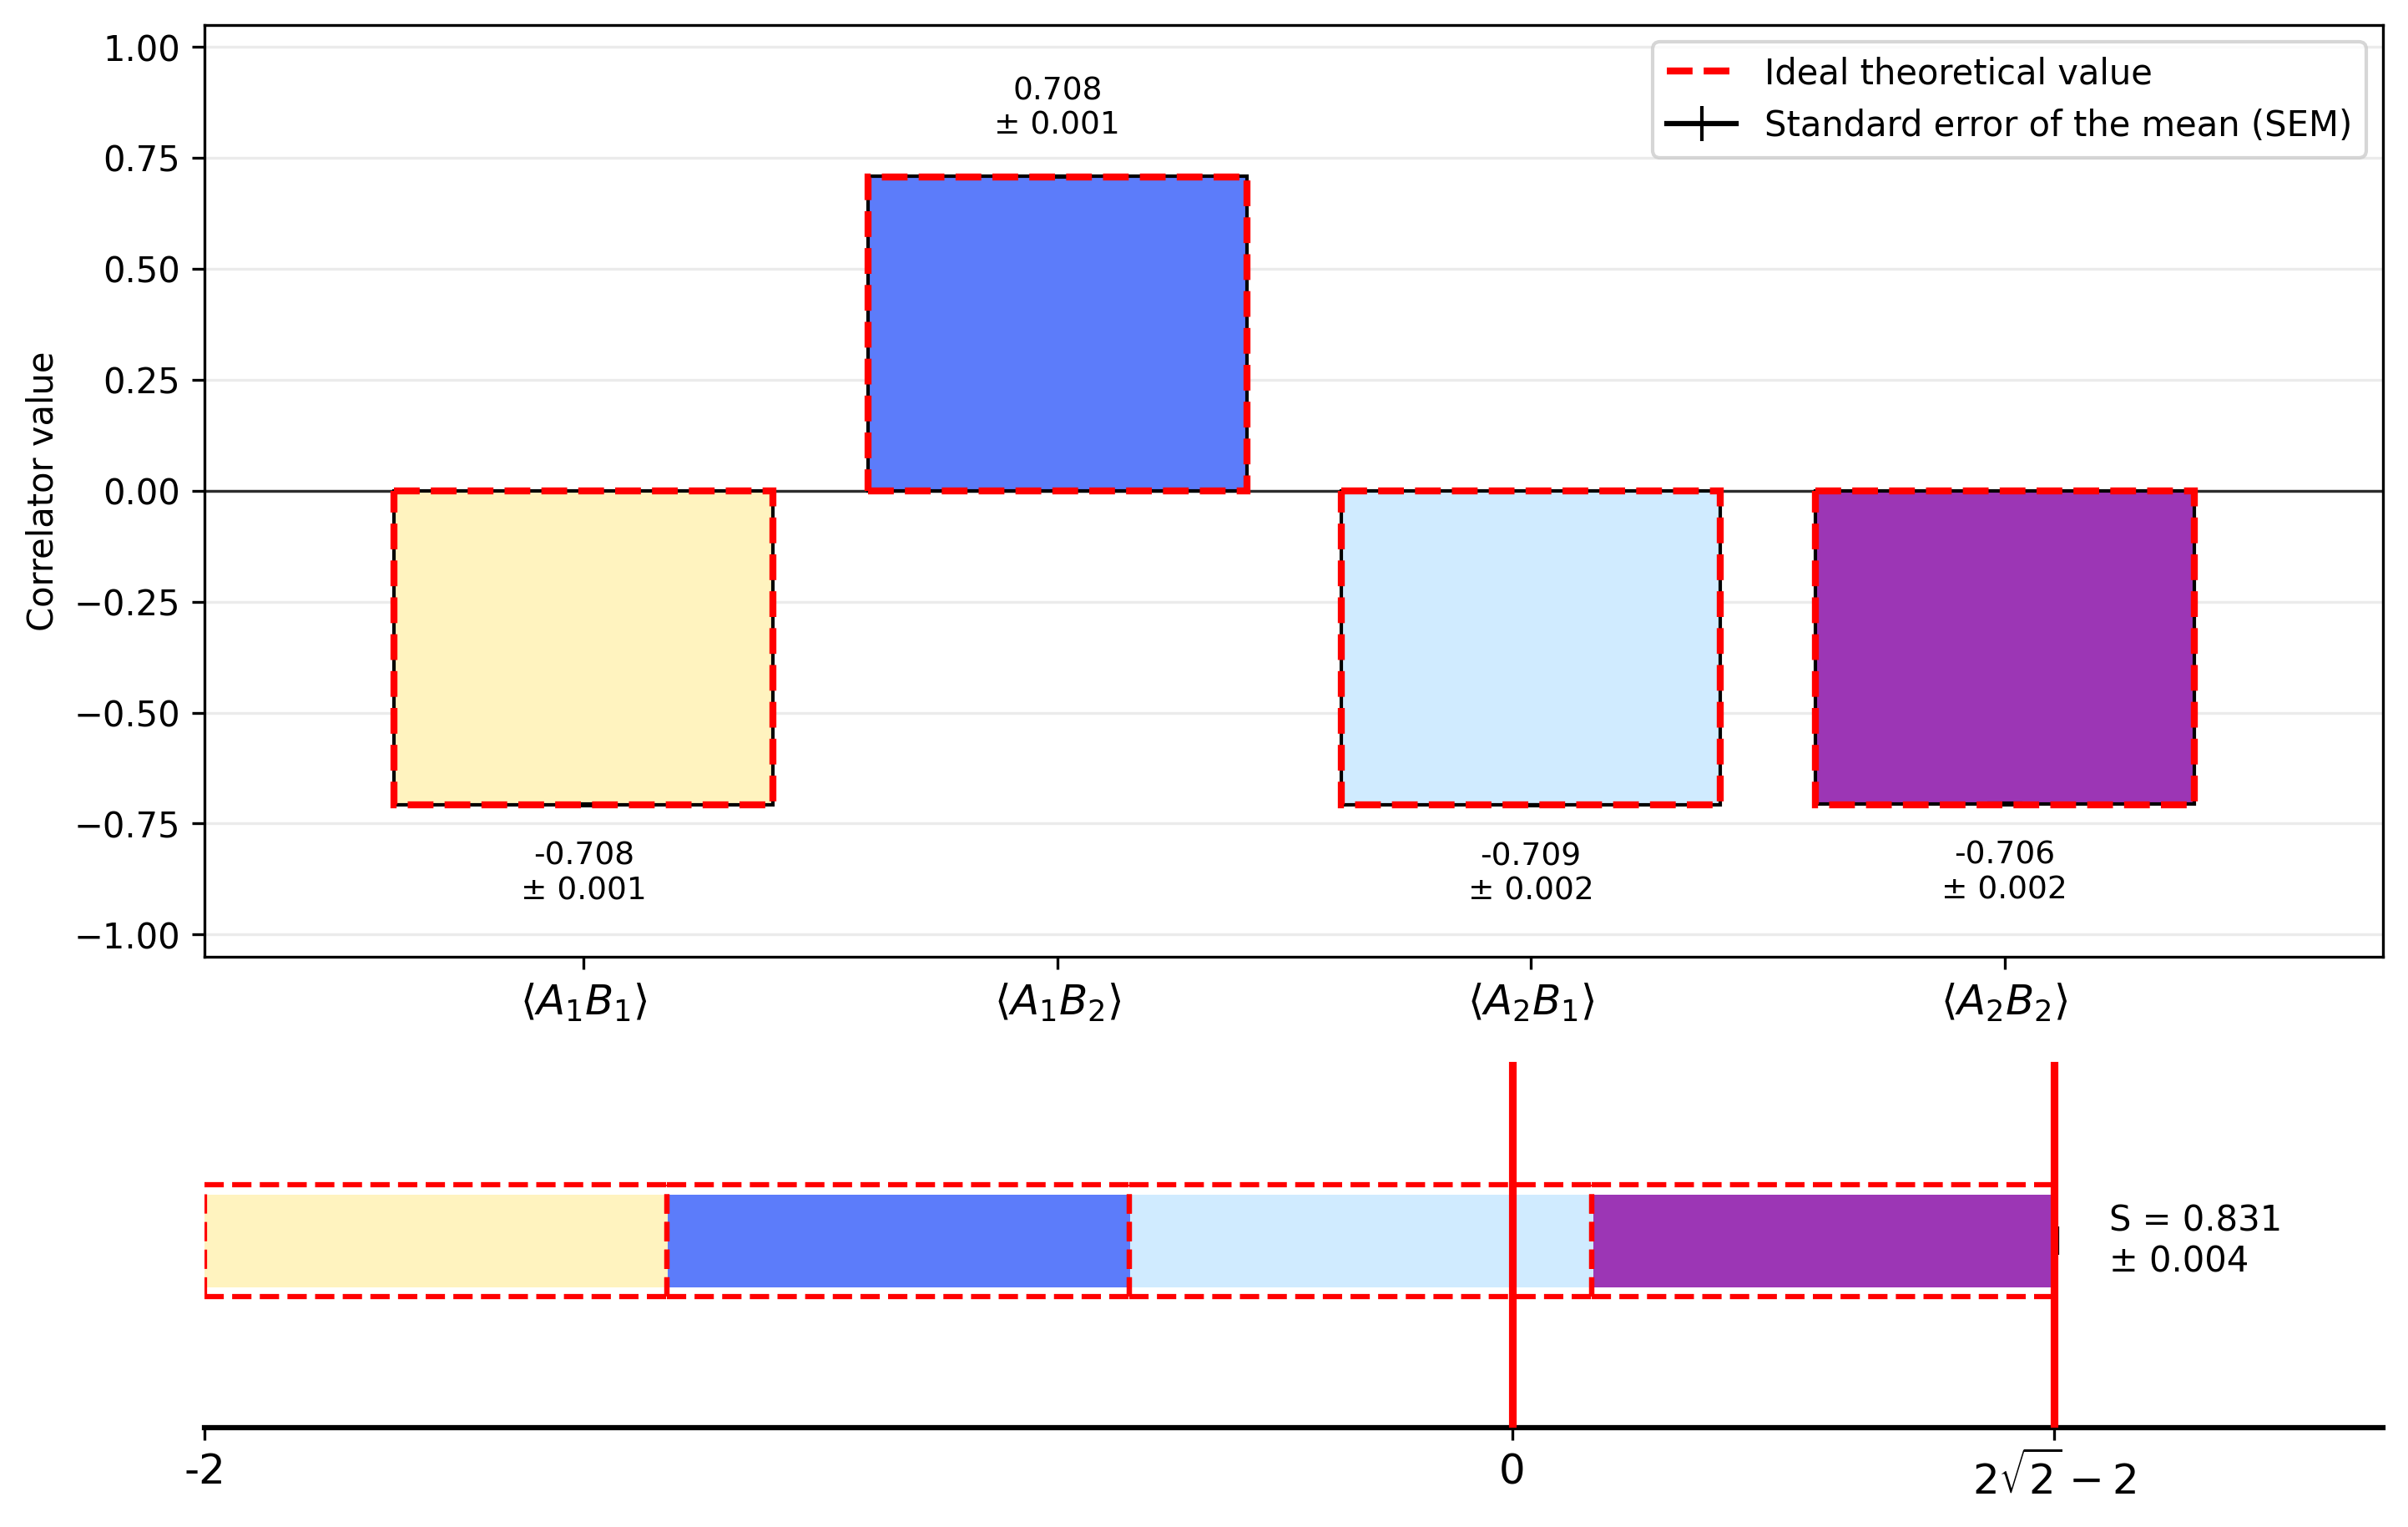

### Noise simulation and hardware LF correlators: Betting Agent

results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_betting_agent_lf_correlator_comparison.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_comparison_betting_agent_lf_correlator_comparison.pdf


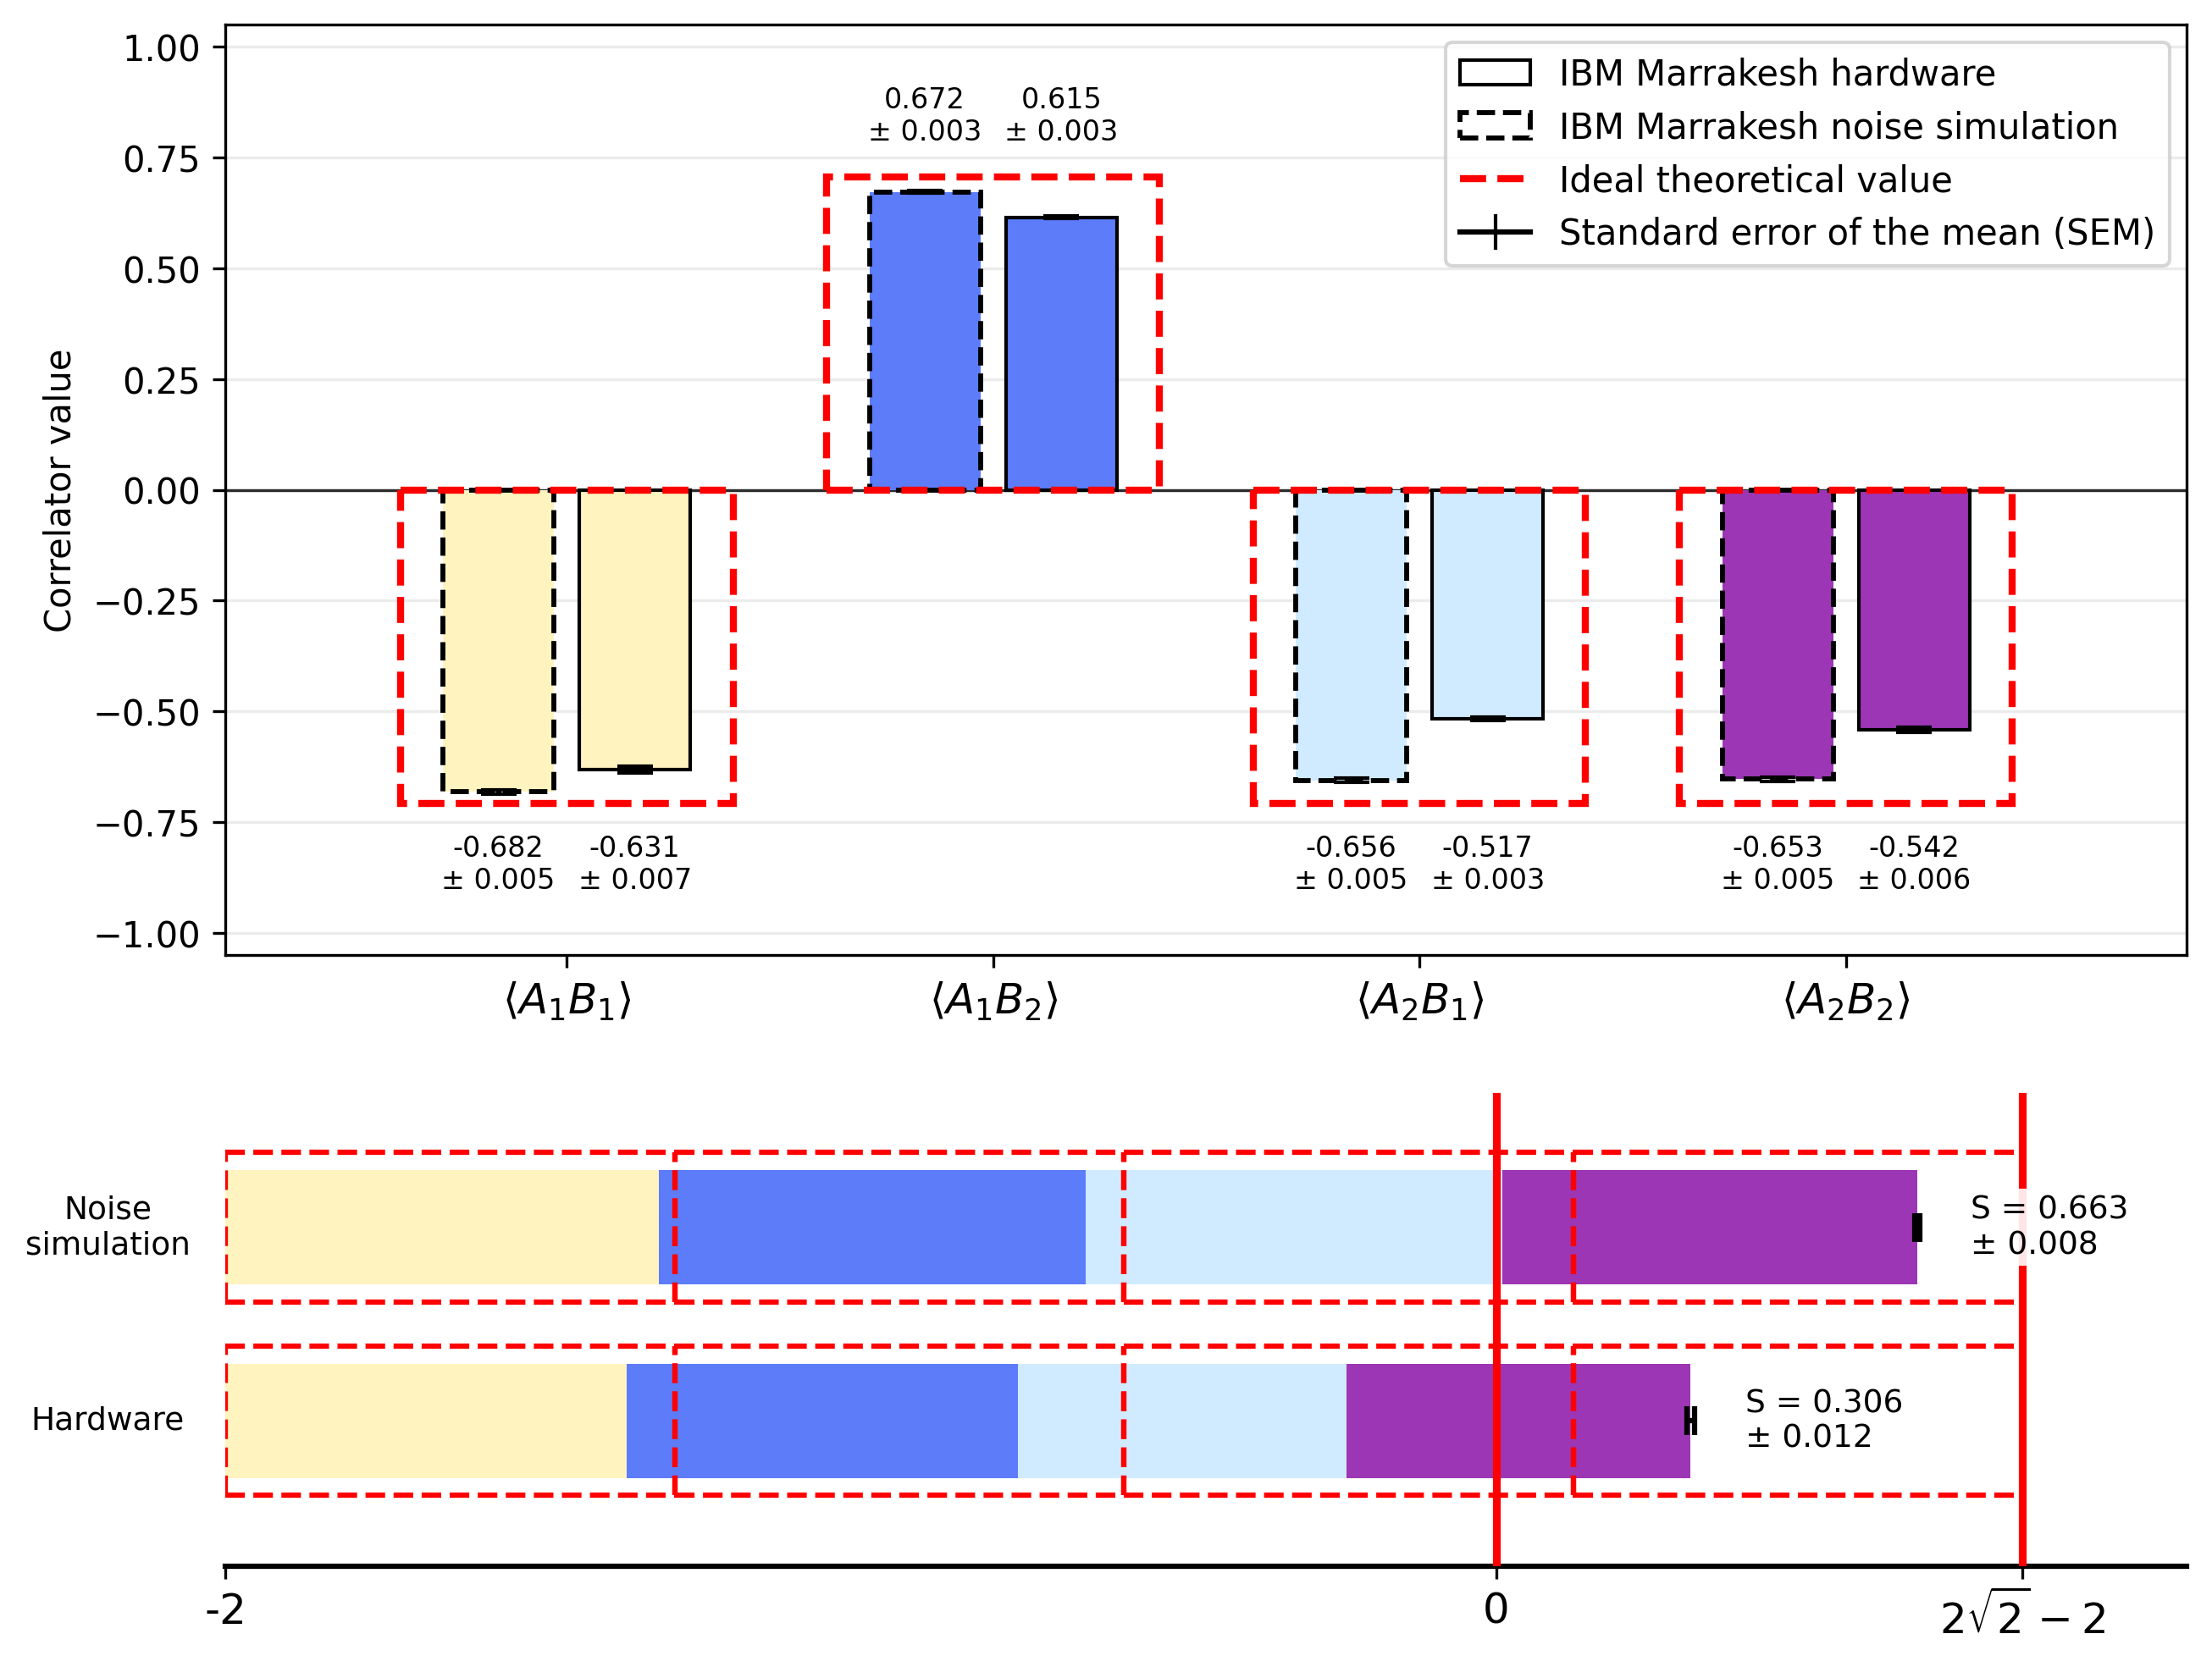

In [6]:
def show_plot(title, path):
    display(Markdown(f"### {title}"))
    print(path.relative_to(PROJECT_ROOT))
    print(pdf_plot_path(path).relative_to(PROJECT_ROOT))
    display(Image(filename=str(path)))

show_plot("Hardware LF violation summary", figure_paths["lf_hardware_summary"])

for agent_name in DISPLAY_AGENT_ORDER:
    show_plot(f"Noiseless LF correlators: {agent_name}", figure_paths["lf_noiseless_by_agent"][agent_name])
    show_plot(f"Noise simulation and hardware LF correlators: {agent_name}", figure_paths["lf_hardware_comparison_by_agent"][agent_name])

## Agent Evaluations

### Reflex Agent accuracy

results/plots/project_plots/20260429_234359/accuracy_plots/reflex_agent_accuracy_comparison.png
results/plots/project_plots/20260429_234359/accuracy_plots/reflex_agent_accuracy_comparison.pdf


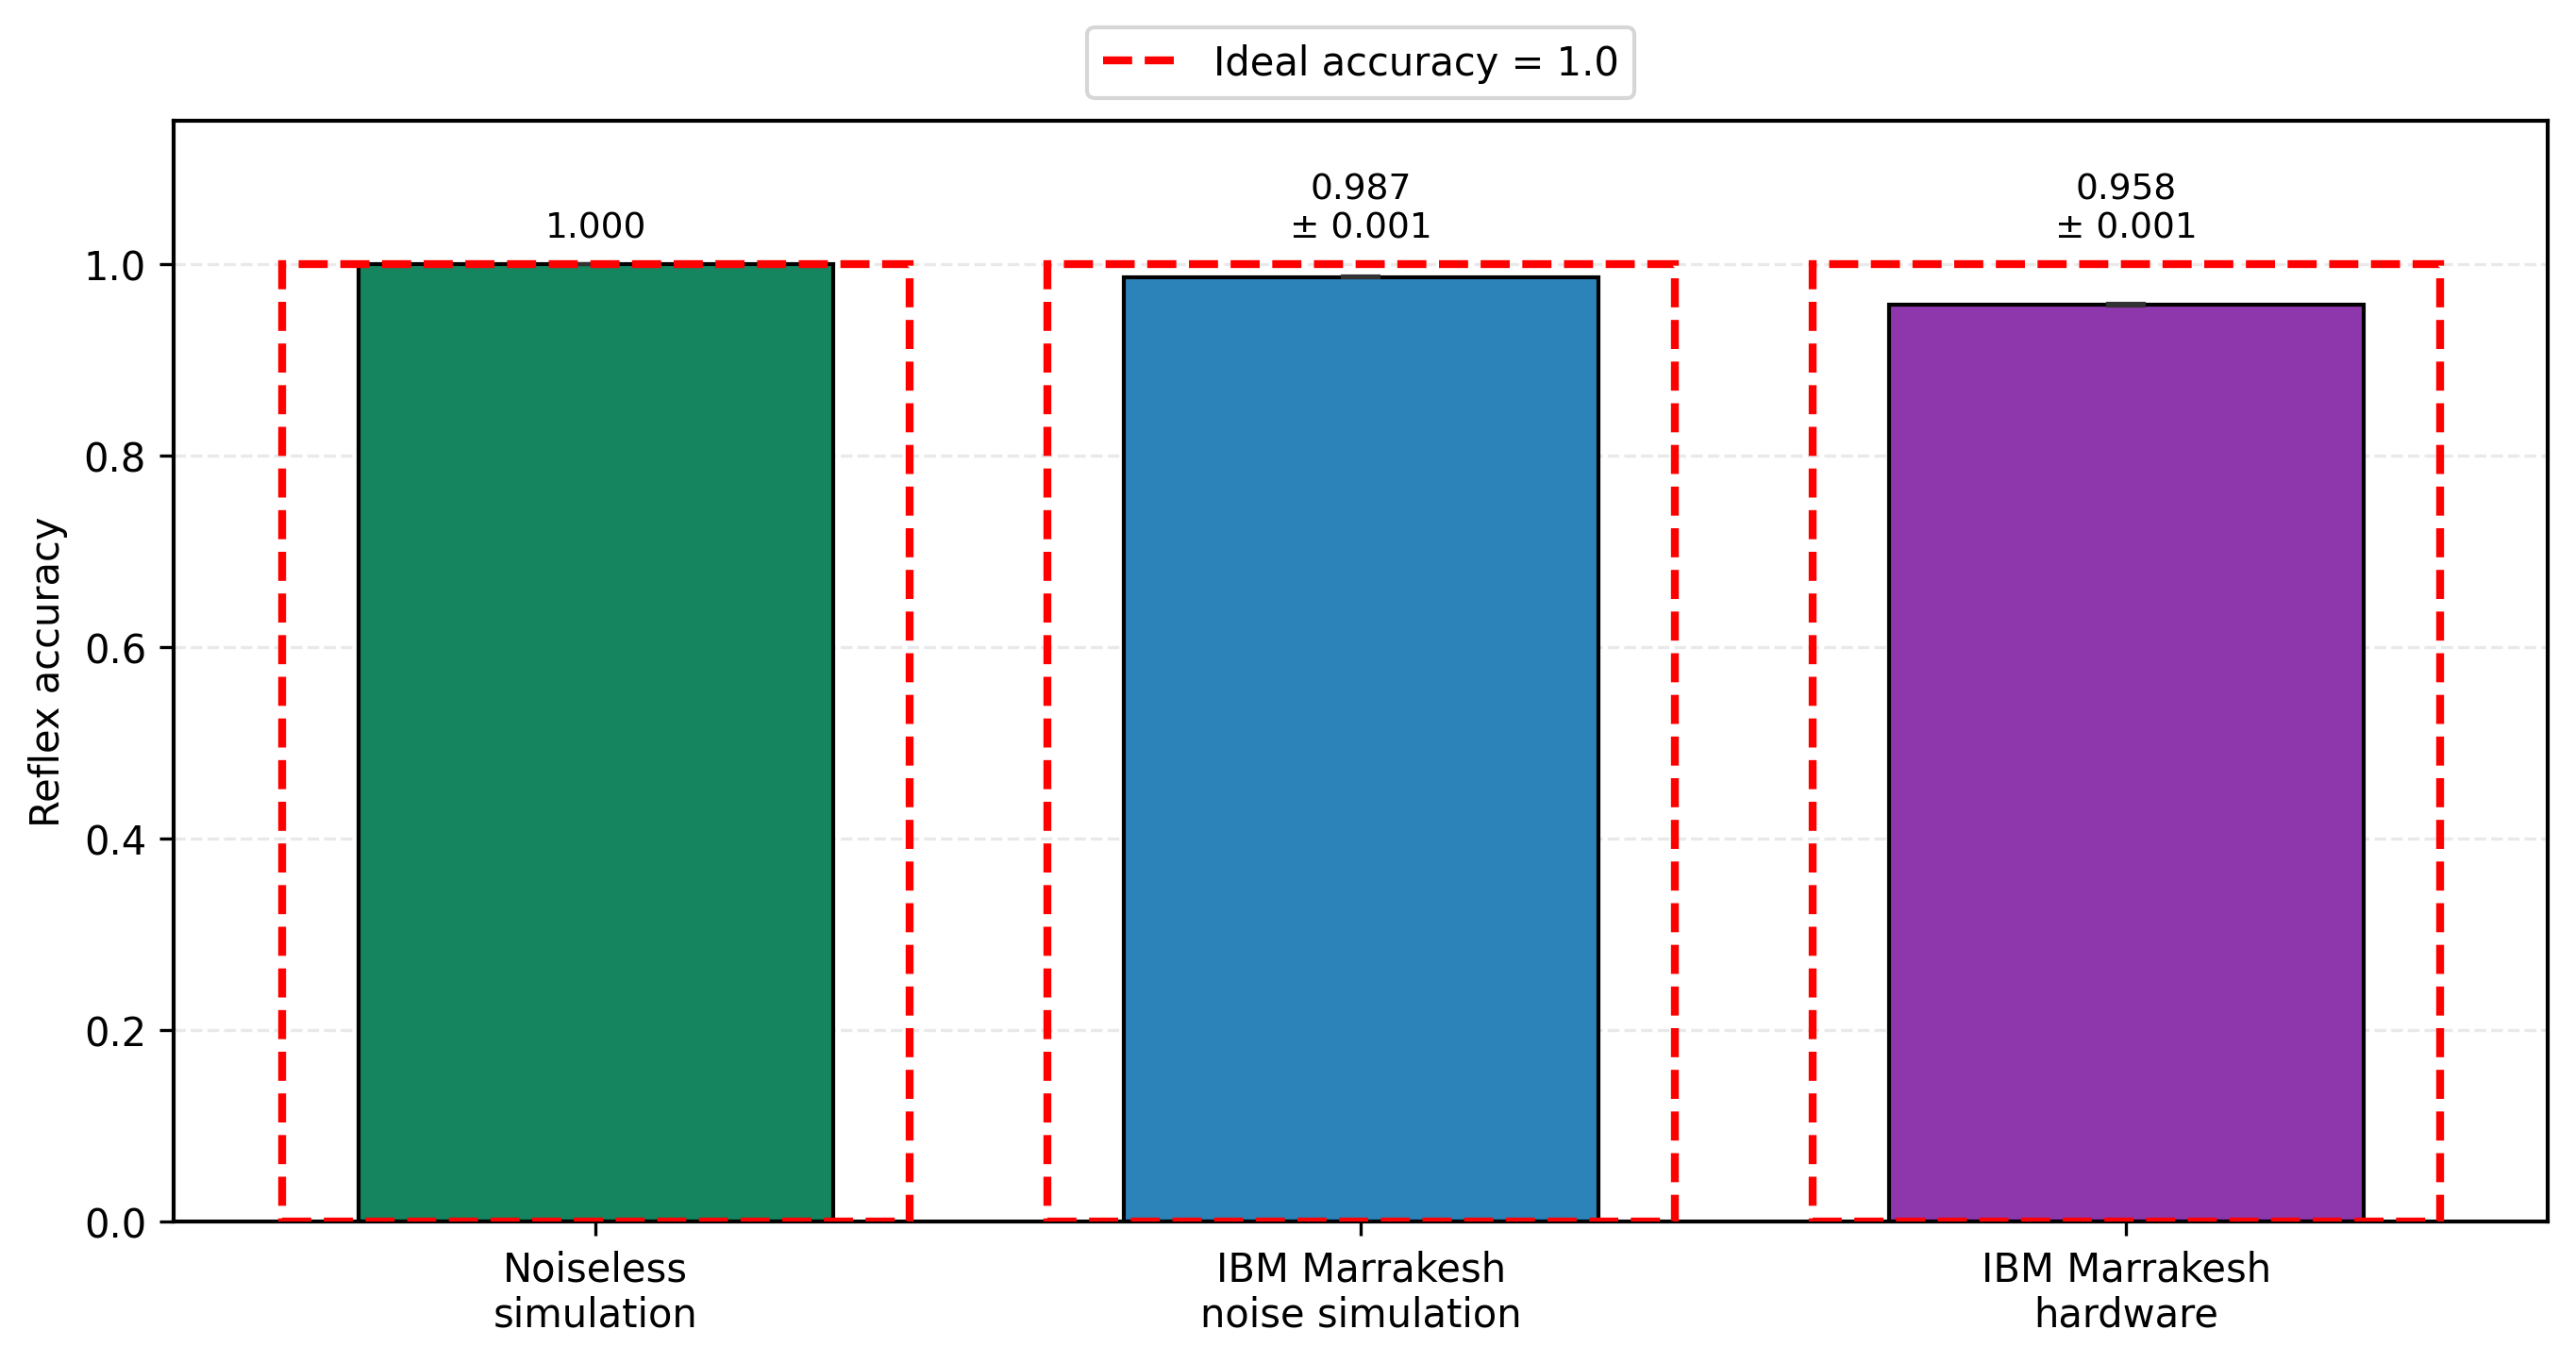

### Reflex Agent S_A/M agreement

results/plots/project_plots/20260429_234359/accuracy_plots/reflex_agent_sa_m_agreement_accuracy.png
results/plots/project_plots/20260429_234359/accuracy_plots/reflex_agent_sa_m_agreement_accuracy.pdf


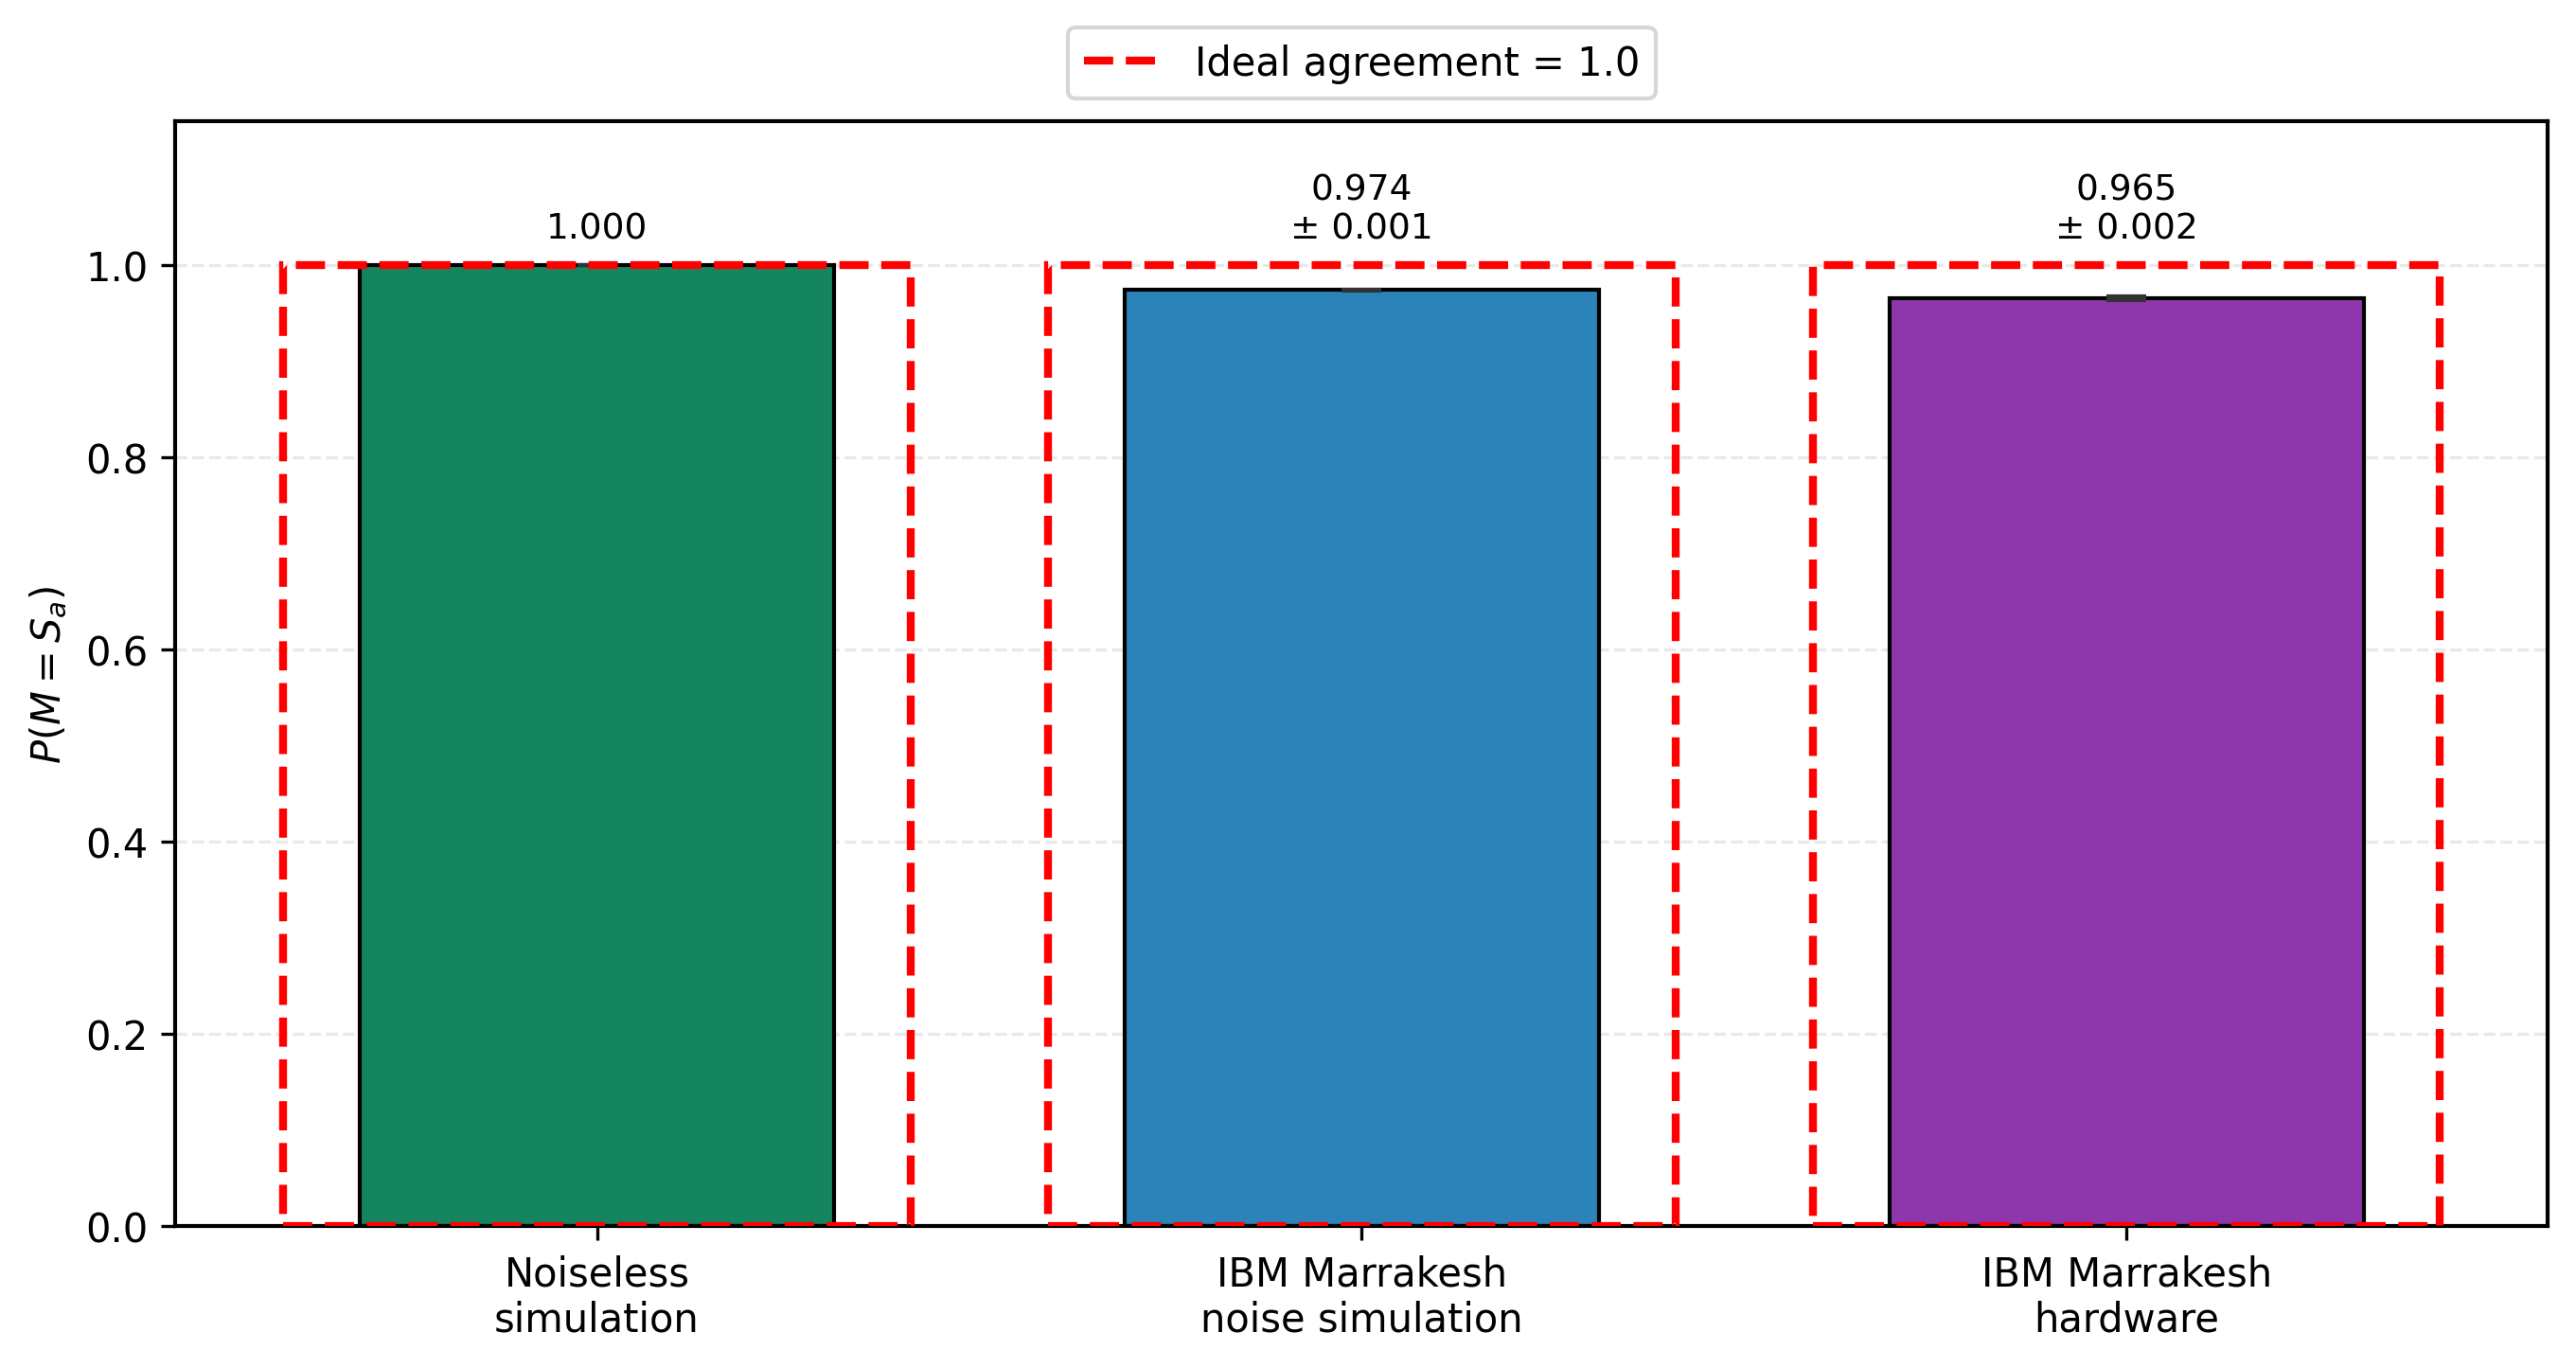

### Guessing Agent accuracy

results/plots/project_plots/20260429_234359/accuracy_plots/guessing_agent_accuracy_comparison.png
results/plots/project_plots/20260429_234359/accuracy_plots/guessing_agent_accuracy_comparison.pdf


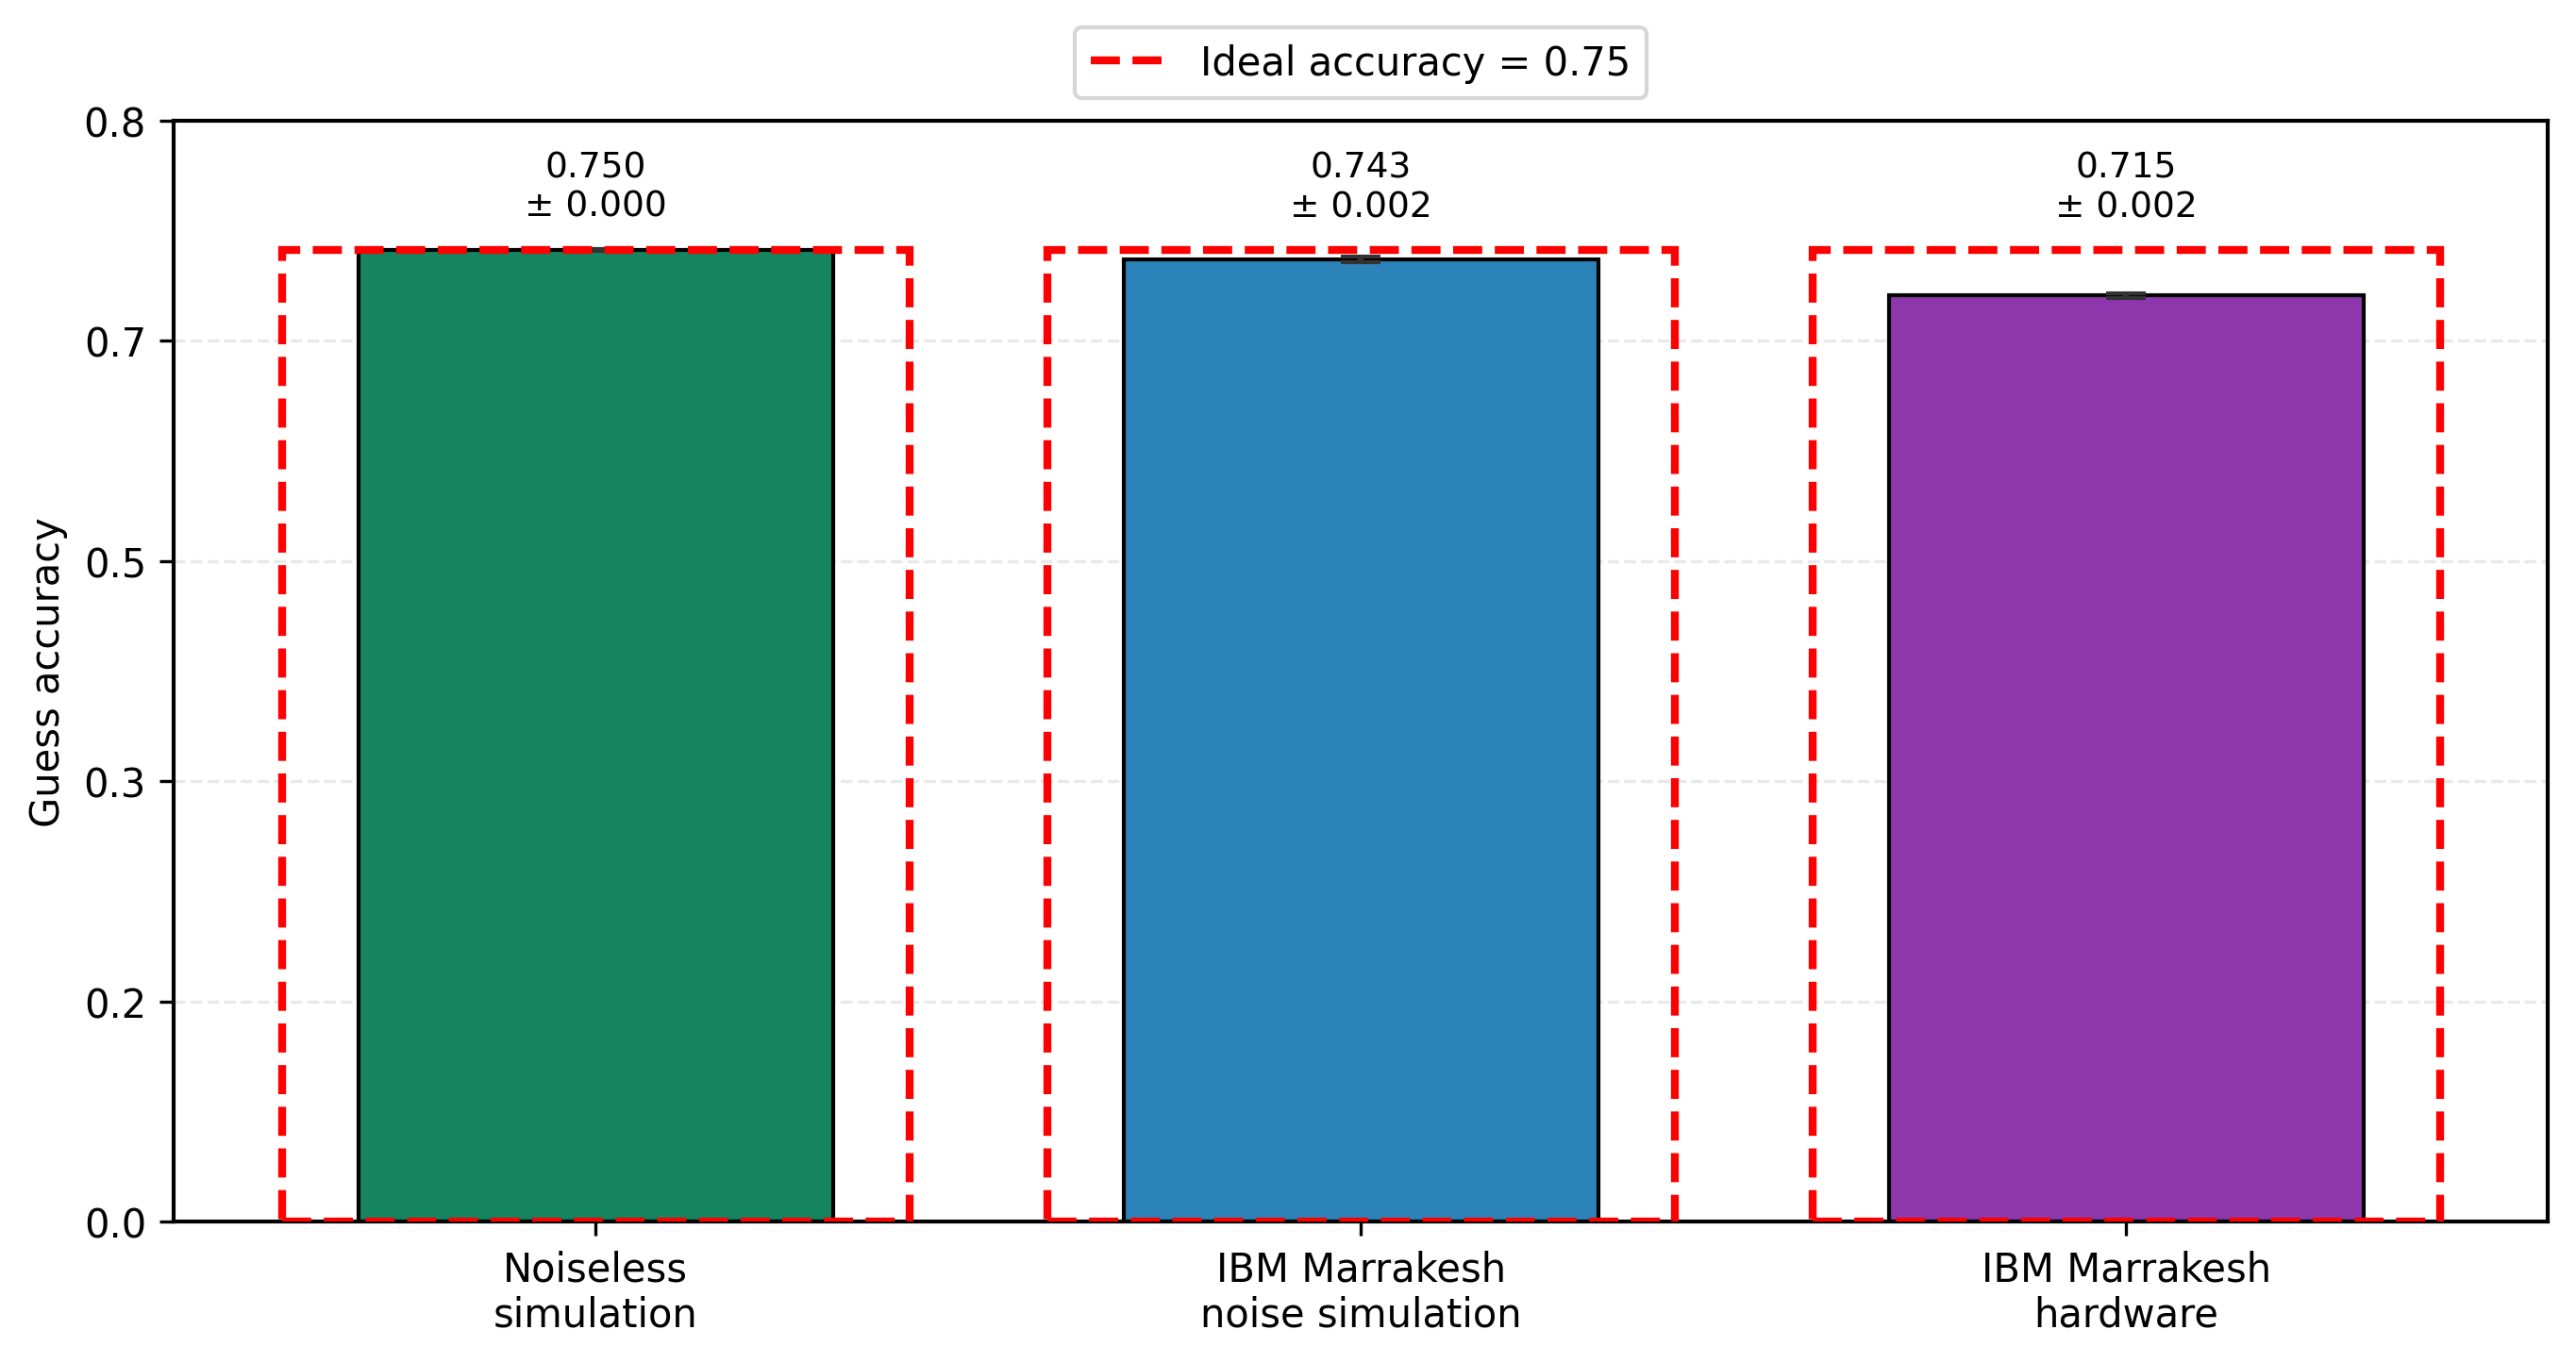

### Always 3/4 Agent accuracy

results/plots/project_plots/20260429_234359/accuracy_plots/always_3_4_agent_accuracy_comparison.png
results/plots/project_plots/20260429_234359/accuracy_plots/always_3_4_agent_accuracy_comparison.pdf


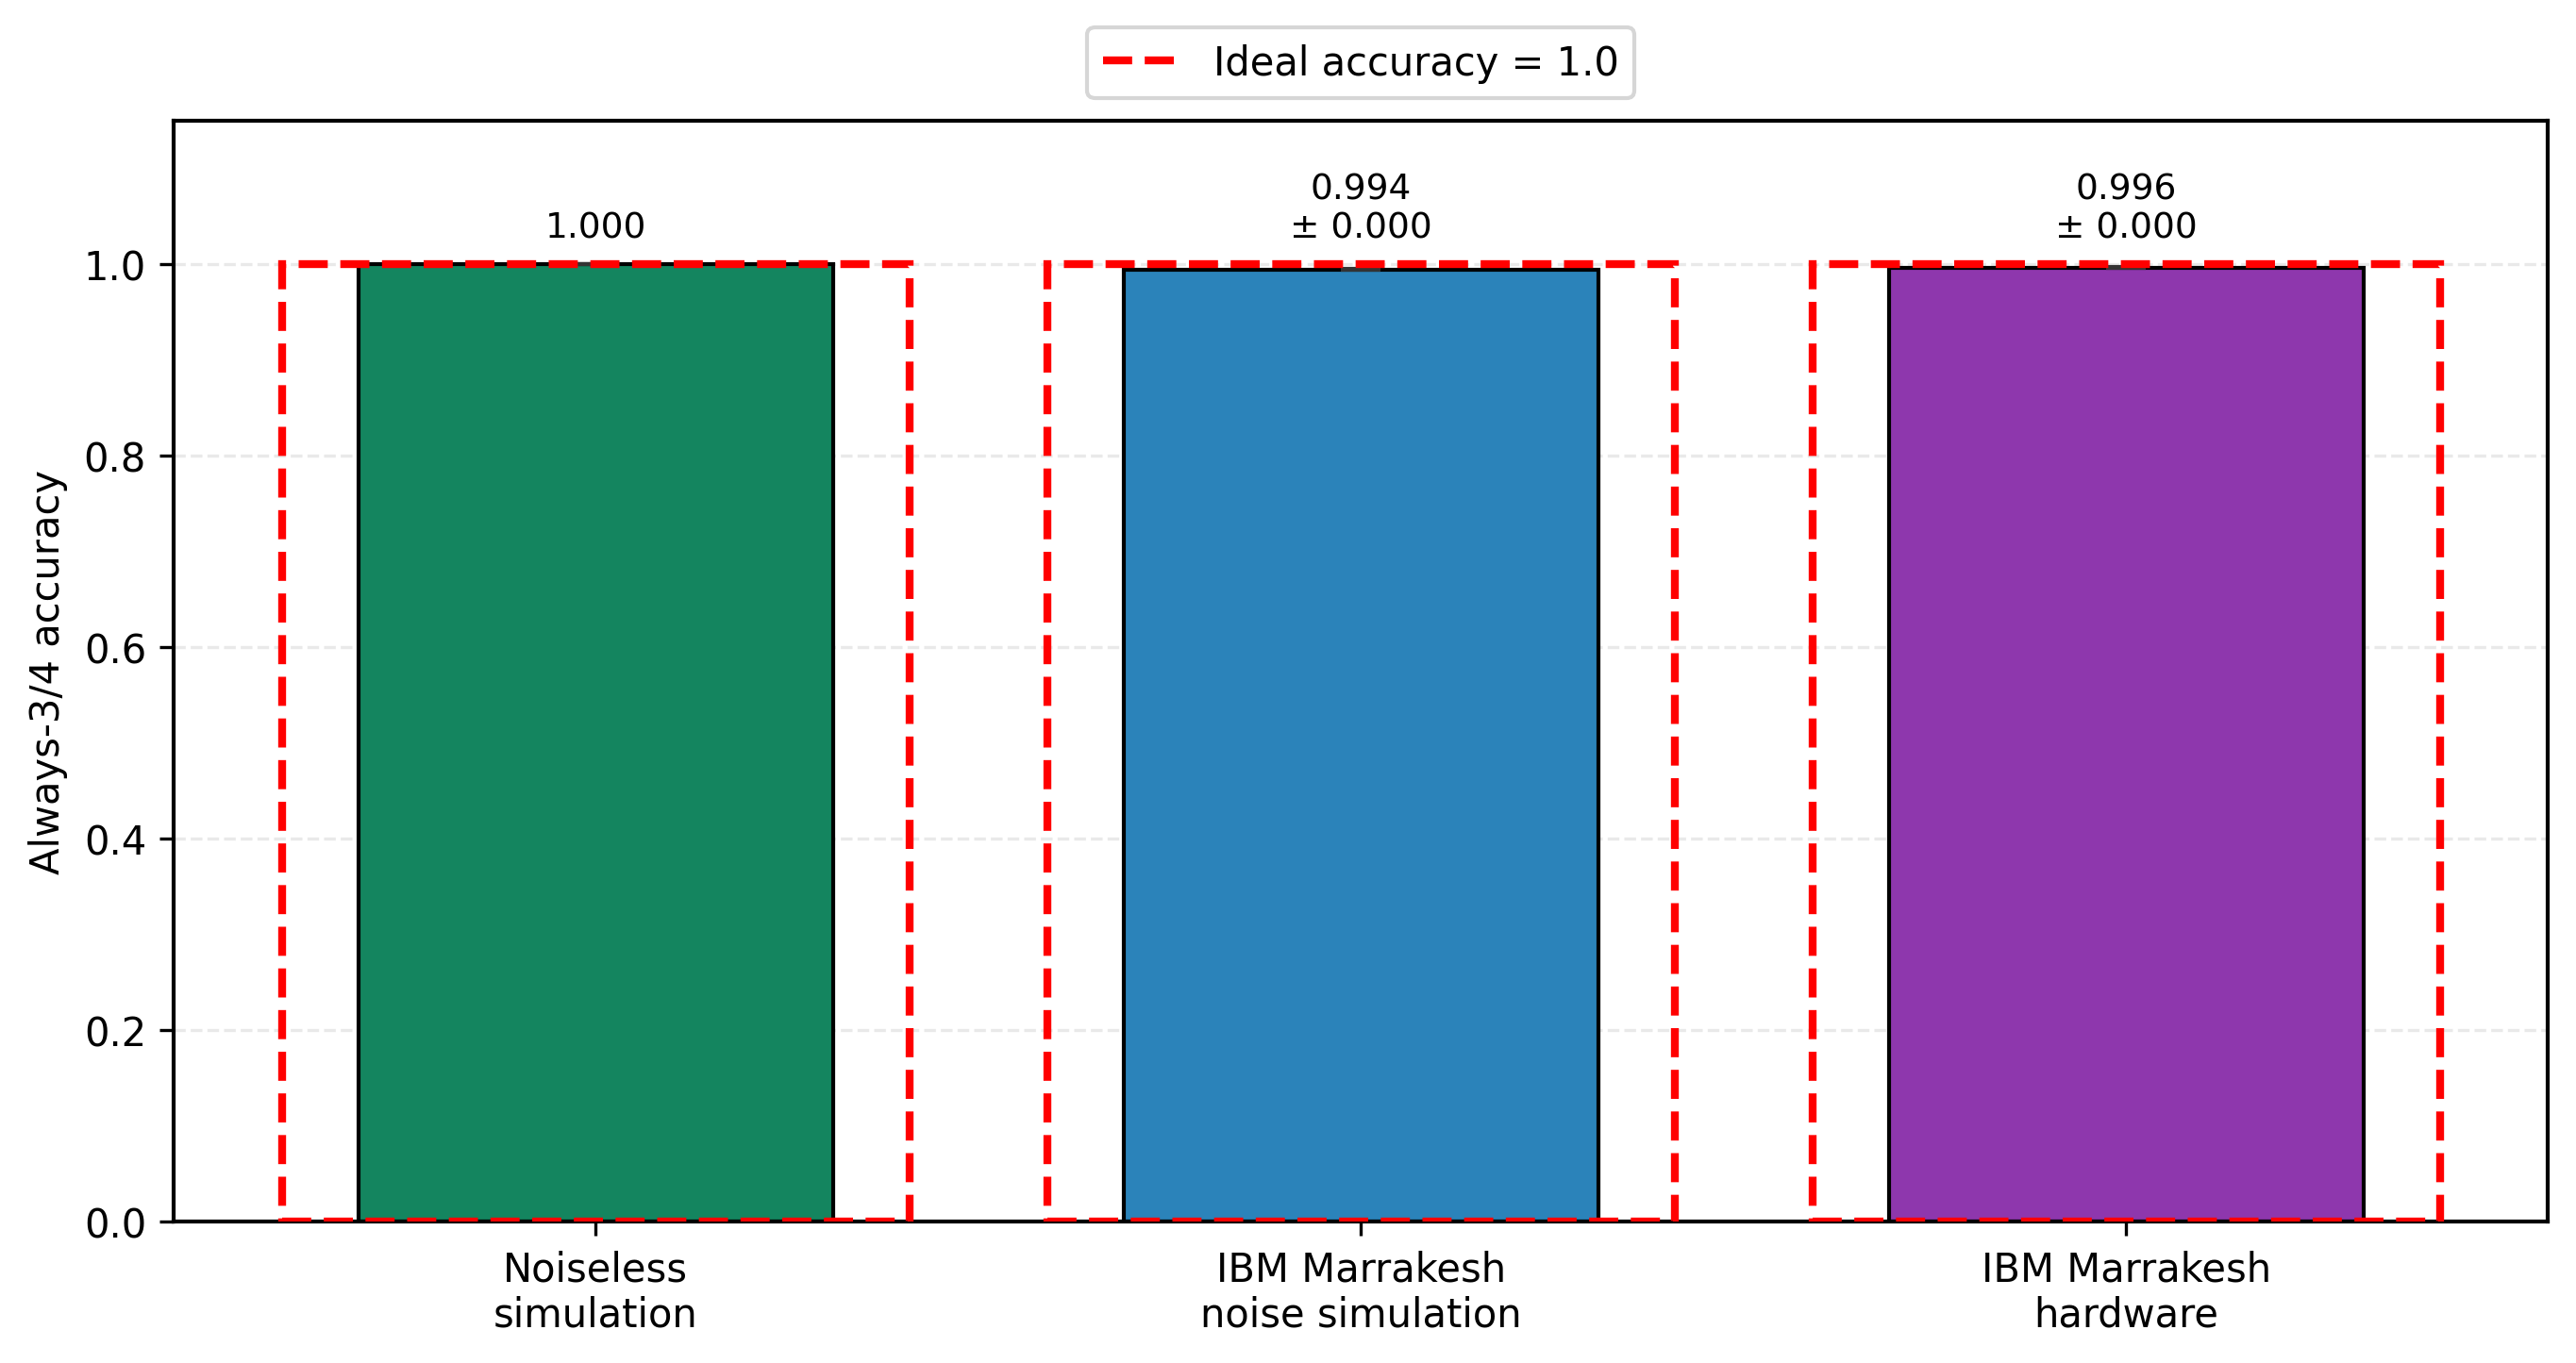

### Betting Agent accuracy

results/plots/project_plots/20260429_234359/accuracy_plots/betting_agent_accuracy_comparison.png
results/plots/project_plots/20260429_234359/accuracy_plots/betting_agent_accuracy_comparison.pdf


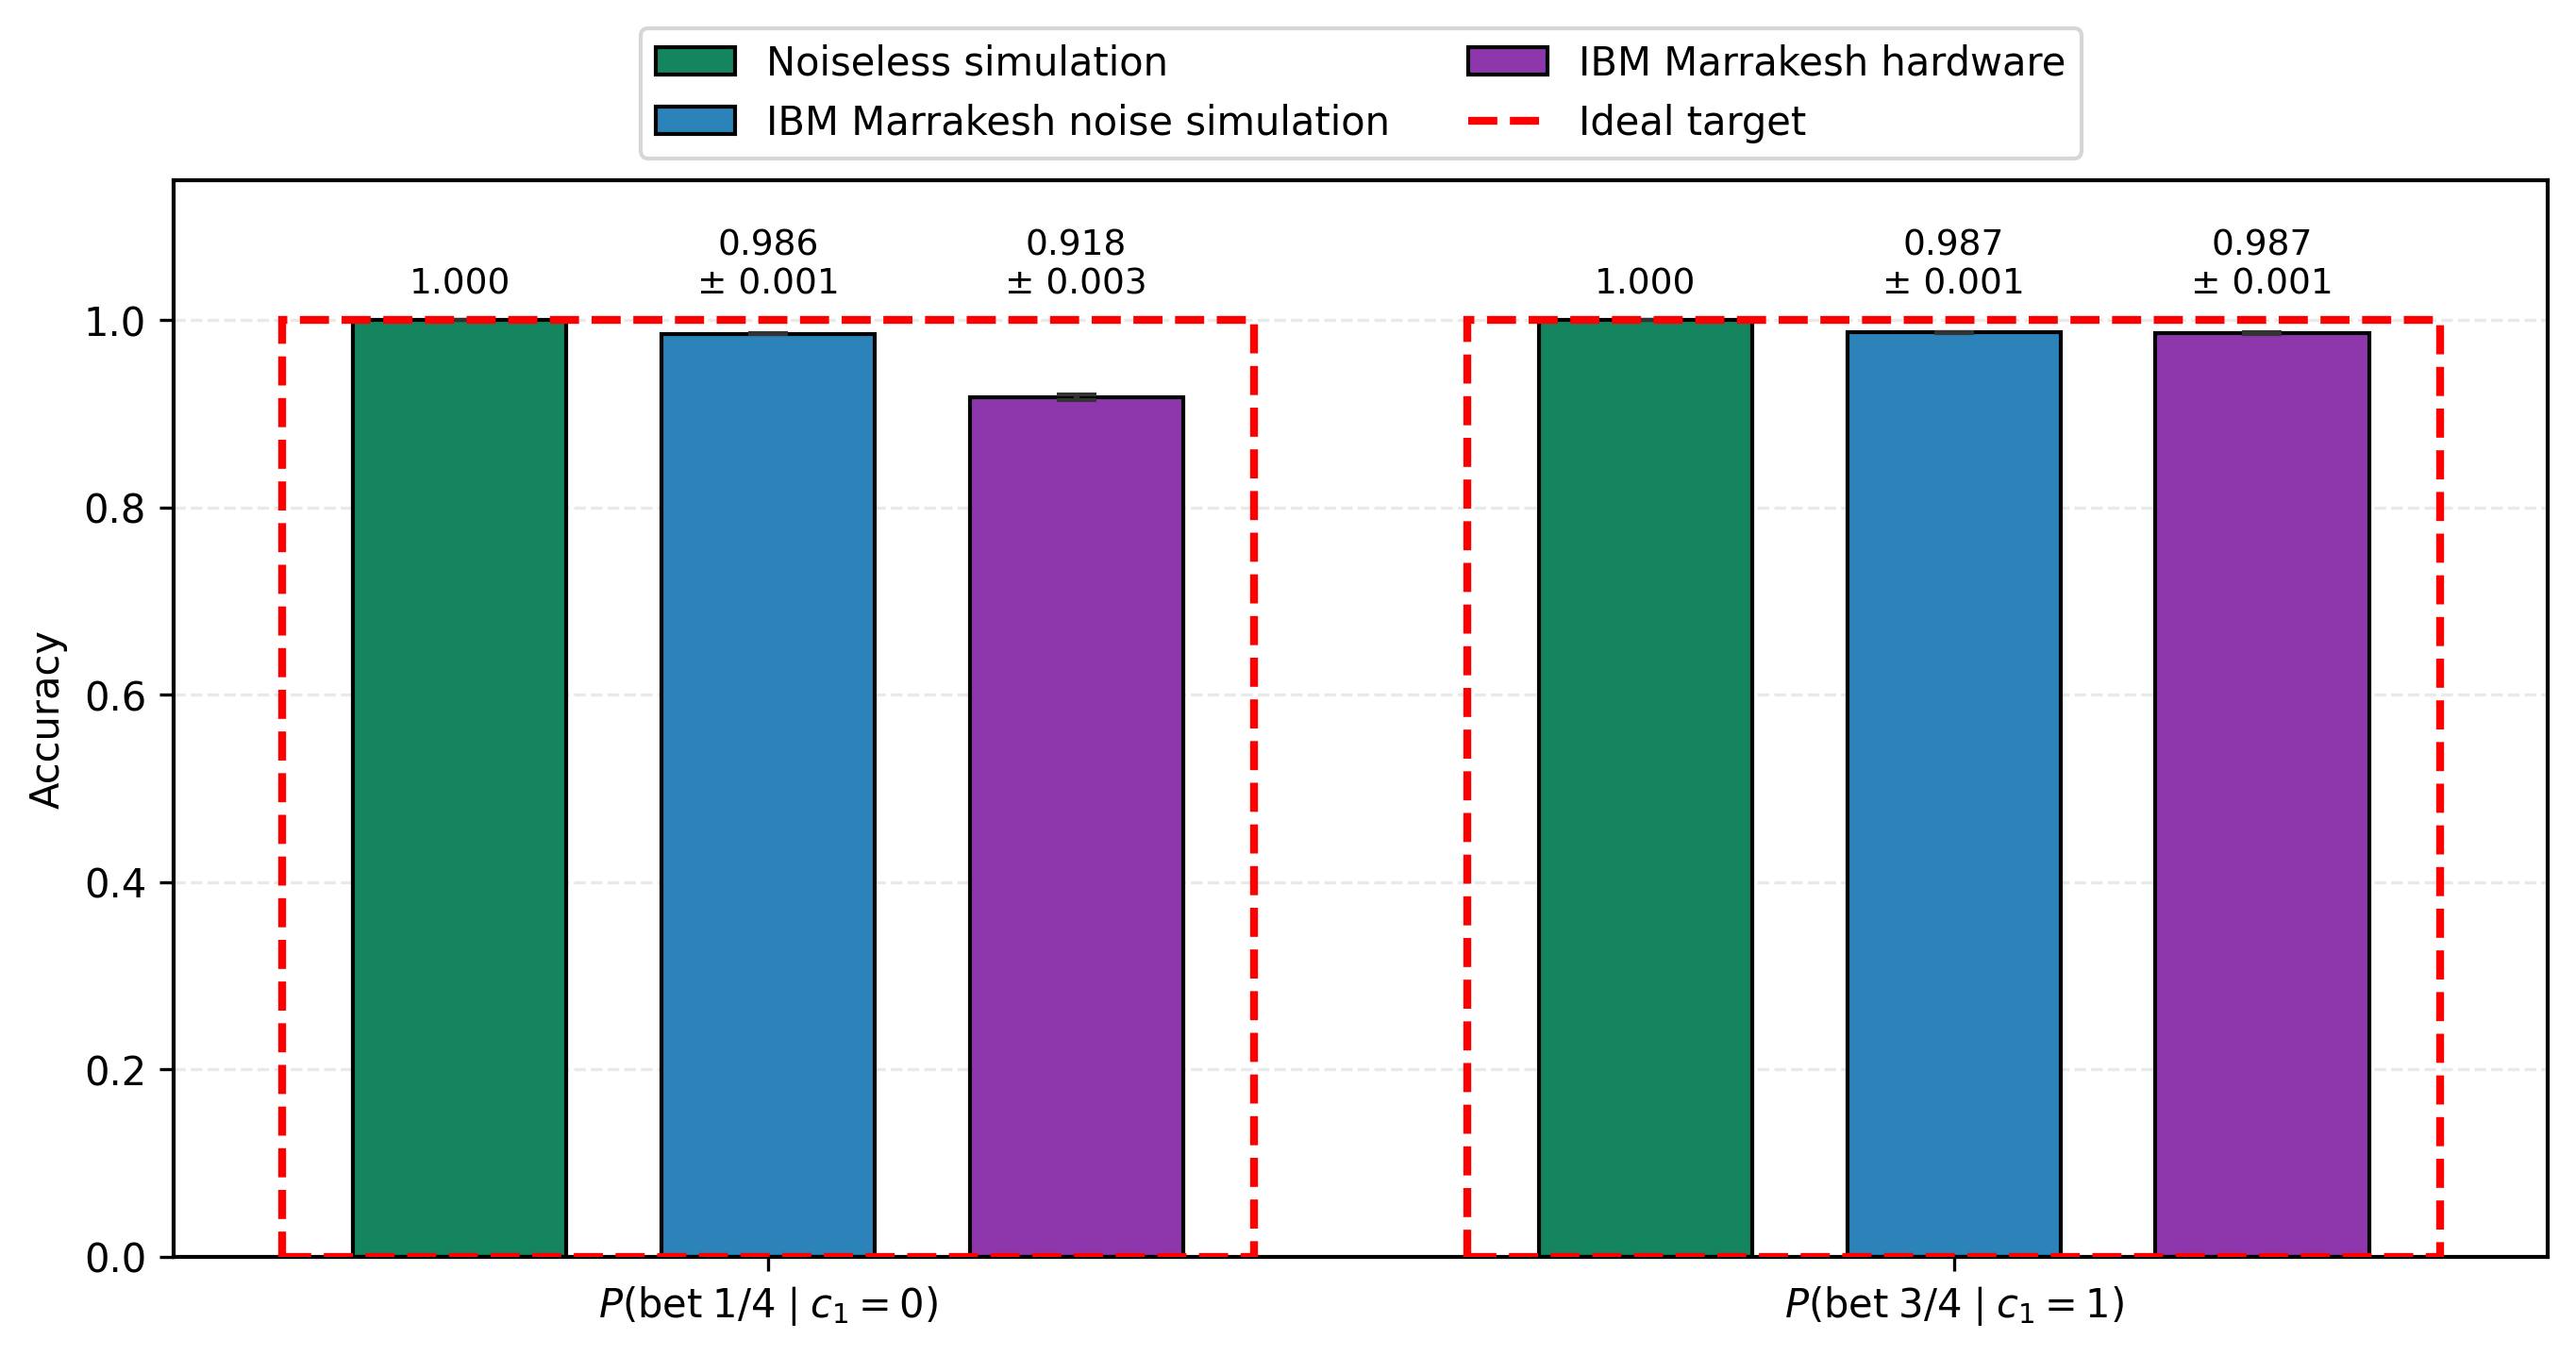

### Betting Agent vs Always 3/4 payoff

results/plots/project_plots/20260429_234359/payout_comparison/betting_agent_vs_always_3_4_payoff_comparison.png
results/plots/project_plots/20260429_234359/payout_comparison/betting_agent_vs_always_3_4_payoff_comparison.pdf


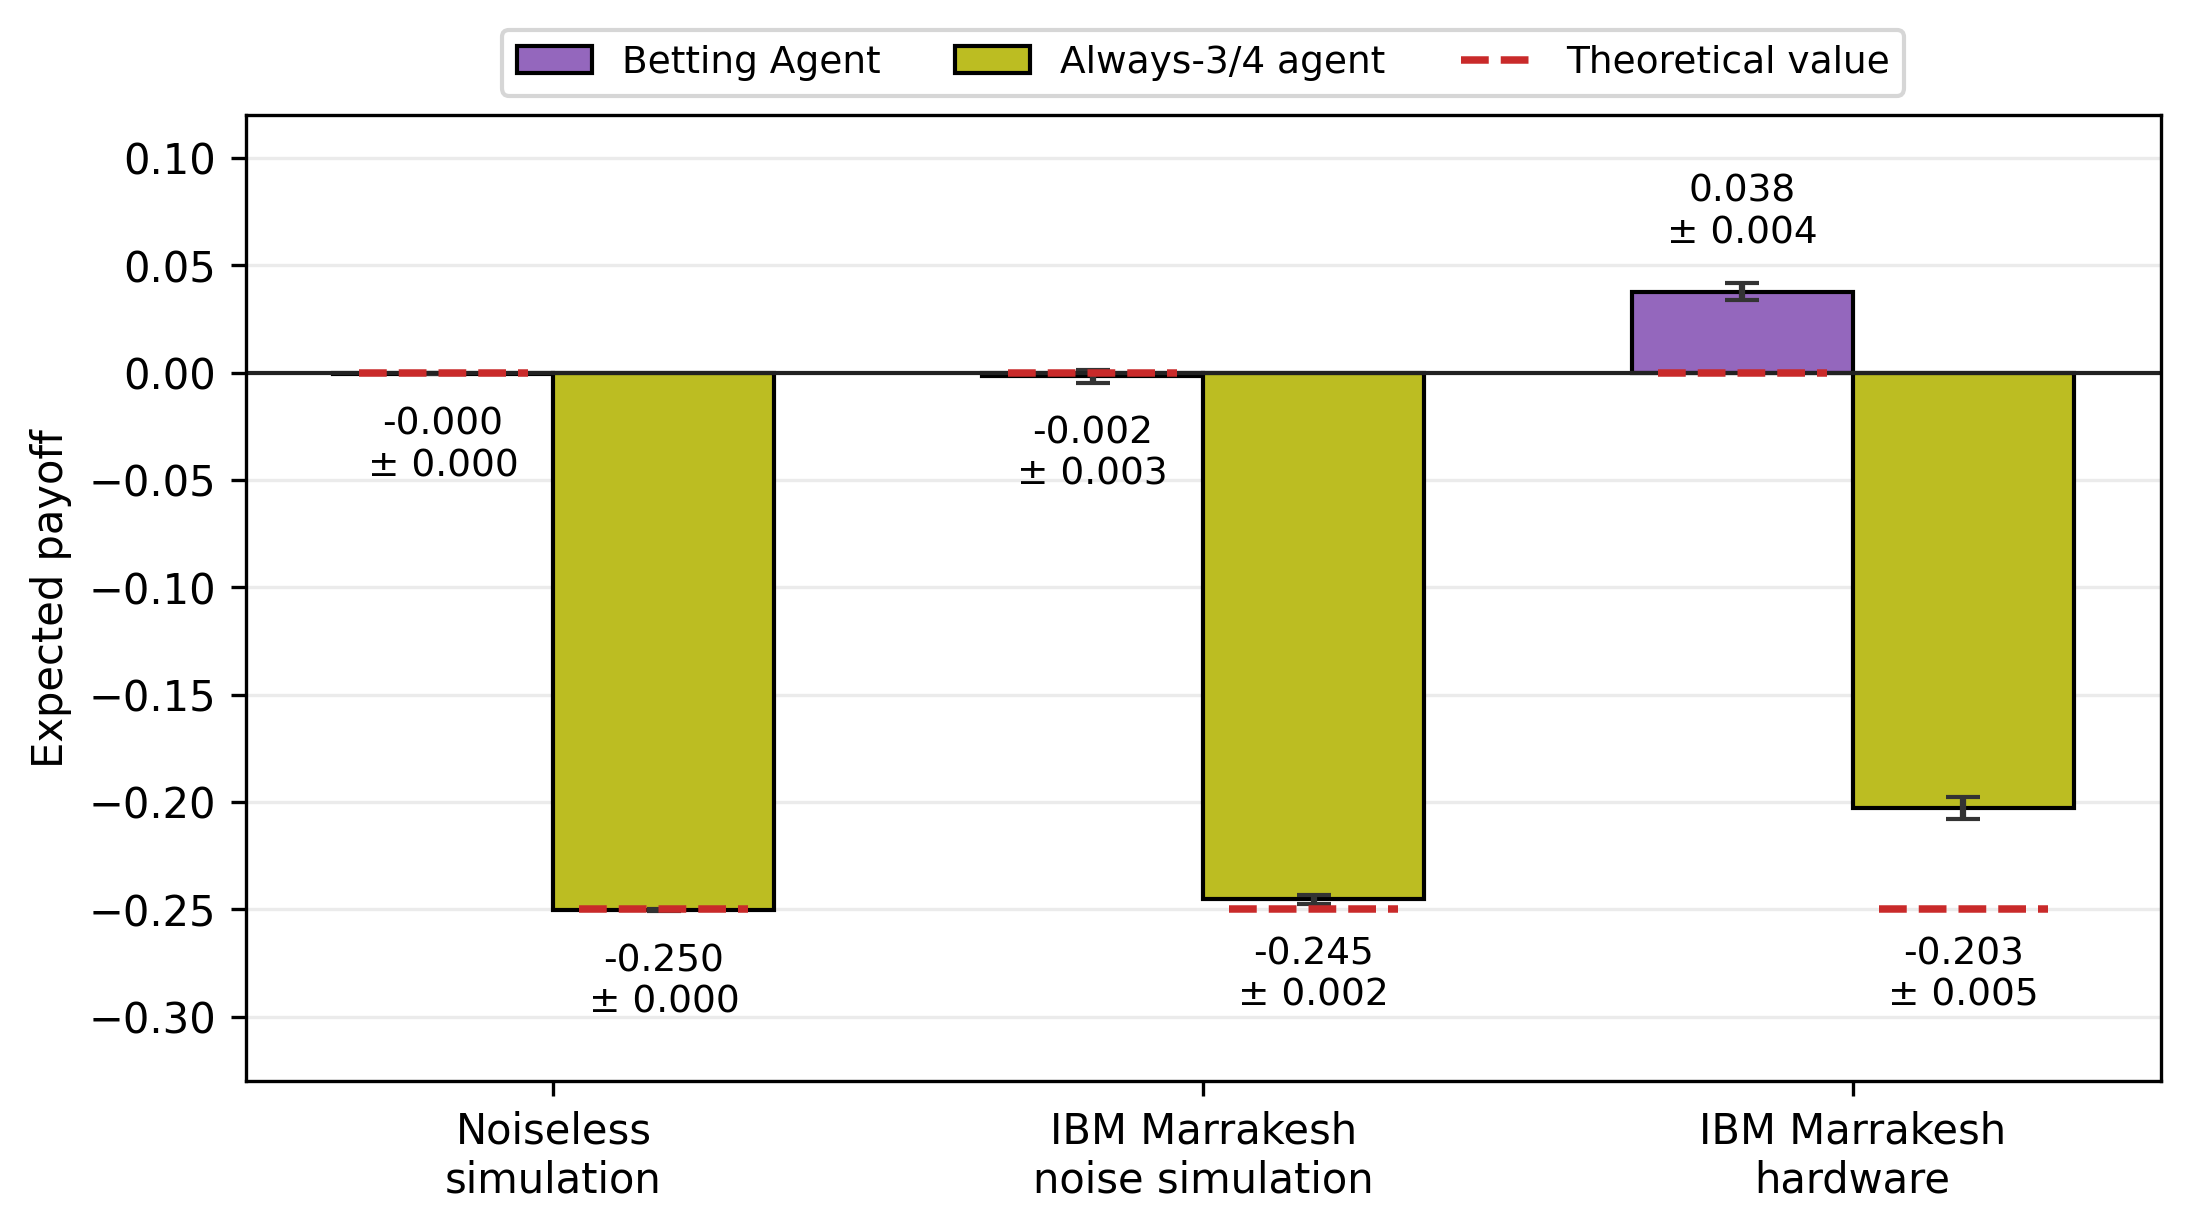

In [7]:
show_plot("Reflex Agent accuracy", figure_paths["reflex_accuracy"])
show_plot("Reflex Agent S_A/M agreement", figure_paths["reflex_sa_m_accuracy"])
show_plot("Guessing Agent accuracy", figure_paths["guessing_accuracy"])
show_plot("Always 3/4 Agent accuracy", figure_paths["always_3_4_accuracy"])
show_plot("Betting Agent accuracy", figure_paths["betting_accuracy"])
show_plot("Betting Agent vs Always 3/4 payoff", figure_paths["betting_vs_always_payoff"])

## Relaxed LF Robustness

In [8]:
epsilon_rows = []
real_memory = next(backend for backend in memory_inaccuracy_summary["backends"] if backend["label"] == "Real hardware")
for agent_name in DISPLAY_AGENT_ORDER:
    epsilon = real_memory["combined_agents"].get(agent_name, {})
    epsilon_max = tracking_epsilon_max_summary["agents"].get(agent_name, {})
    epsilon_rows.append({
        "agent": agent_name,
        "epsilon": epsilon.get("epsilon"),
        "epsilon_stderr": epsilon.get("epsilon_stderr"),
        "epsilon_max": epsilon_max.get("epsilon_max"),
    })

pd.DataFrame(epsilon_rows)

,agent,epsilon,epsilon_stderr,epsilon_max
0,Reflex Agent,0.01690,0.001045,0.109697
1,Guessing Agent,0.01940,0.001199,0.099182
2,Always 3/4 Agent,0.01755,0.001615,0.080279
3,Betting Agent,0.01600,0.000634,0.067338


### Tracking epsilon estimate

results/plots/project_plots/20260429_234359/tracking_accuracy/combined_memory_initialization_epsilon_comparison.png
results/plots/project_plots/20260429_234359/tracking_accuracy/combined_memory_initialization_epsilon_comparison.pdf


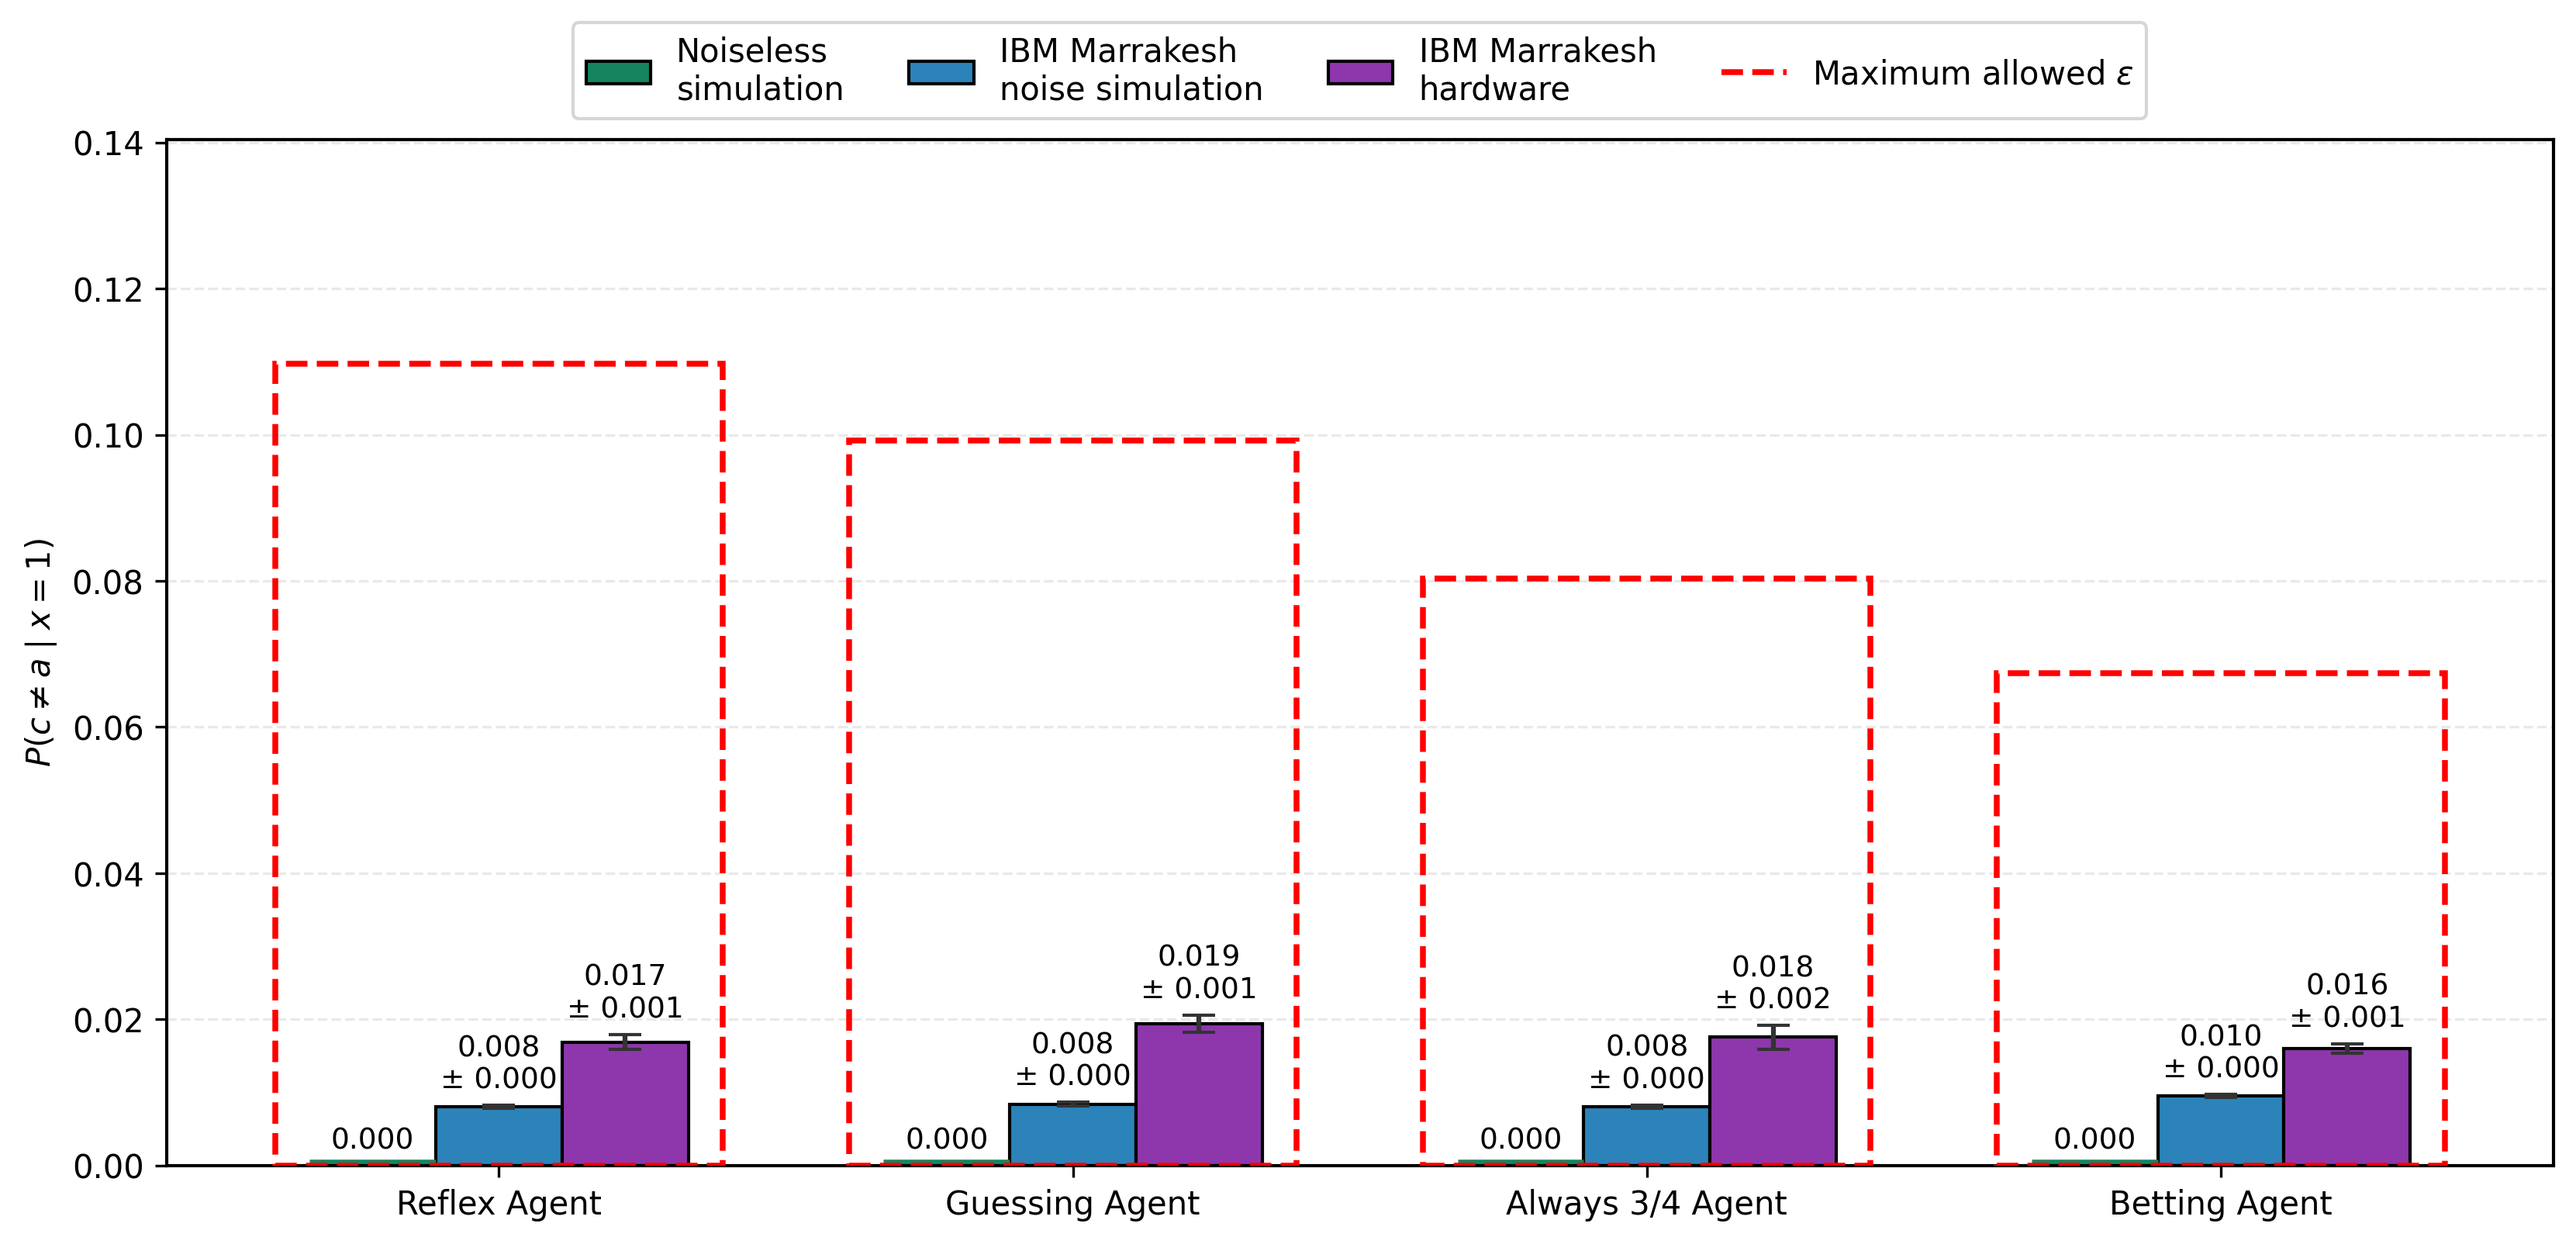

### Hardware LF summary with epsilon bounds

results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_agent_lf_violation_summary_epsilon.png
results/plots/project_plots/20260429_234359/correlators_and_lf_values/comparison/hardware_agent_lf_violation_summary_epsilon.pdf


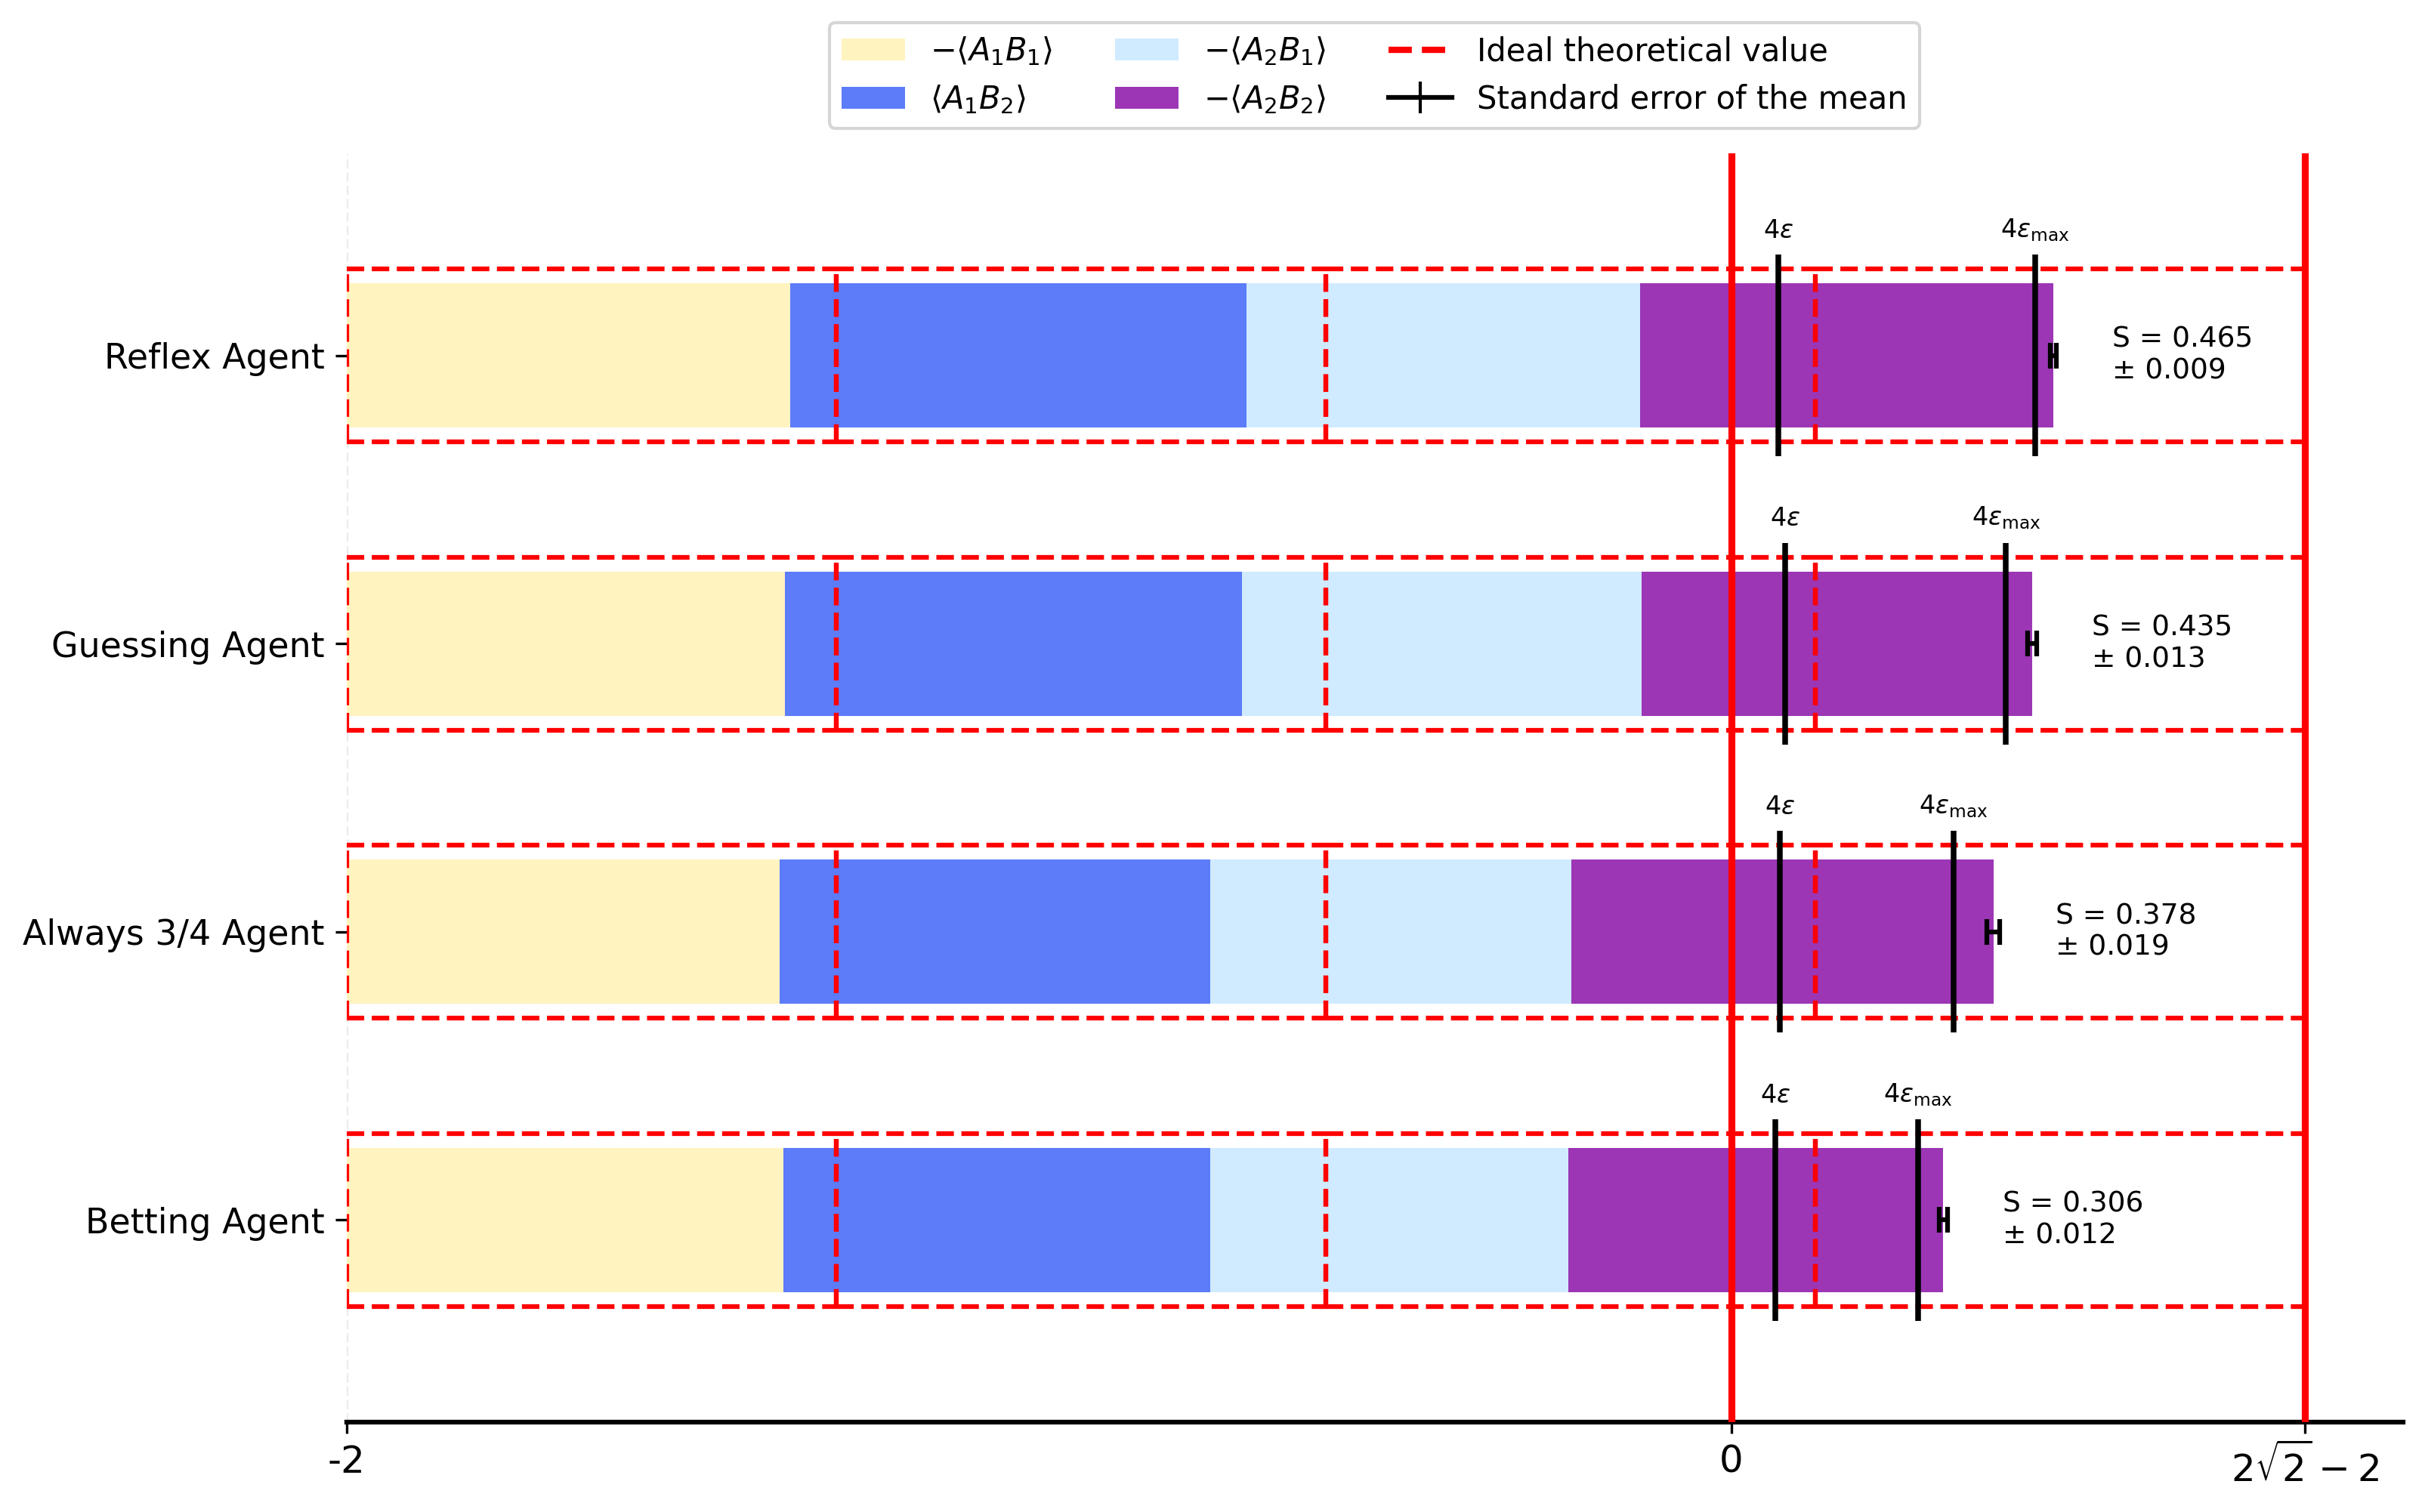

In [9]:
show_plot("Tracking epsilon estimate", figure_paths["tracking_epsilon"])
show_plot("Hardware LF summary with epsilon bounds", figure_paths["lf_hardware_summary_epsilon"])